<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/MONITORAMENTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BIBLIOTECAS NECESSÁRIAS**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ks_2samp
import numpy as np
from sklearn.calibration import calibration_curve

# **BASE DE DADOS**

A base é muito grande para ser colocada no drive e mandada para o colab.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving 2_envio_case_base_Total_2026.csv to 2_envio_case_base_Total_2026 (1).csv


In [75]:
base = pd.read_csv("2_envio_case_base_Total_2026.csv", sep=';')
base.head()

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado
0,534521536,202301,3_5,Chevrolet,"(25000, 70000]",43,solteiro,0,18422,SE,liberais,20,12,2775,0.0,0.0,8,1
1,894445785,202301,10,Chevrolet,"(25000, 70000]",39,solteiro,0,11175,N,empresarios,20,48,734,0.0,0.0,5,1
2,510004819,202301,1_2,Fiat,"(25000, 70000]",37,solteiro,>2,26031,NE,consignados,30,36,1510,1.0,0.0,7,1
3,230978528,202301,10,VW,"(25000, 70000]",61,casado,0,3009,SE,empresarios,20,36,1588,1.0,0.0,4,1
4,489909079,202301,3_5,Fiat,"(25000, 70000]",48,casado,2,10253,CO,assalariados,30,12,2712,0.0,0.0,8,1


# **DEFINIÇÃO DE DATAS**

In [76]:
base['ano_mes'] = pd.to_datetime(base['ano_mes'], format='%Y%m')

# **VARIÁVEL ID**

tipo: chave

descrição: numero de identificação da proposta de crédito

*Diminui em 03/25.*

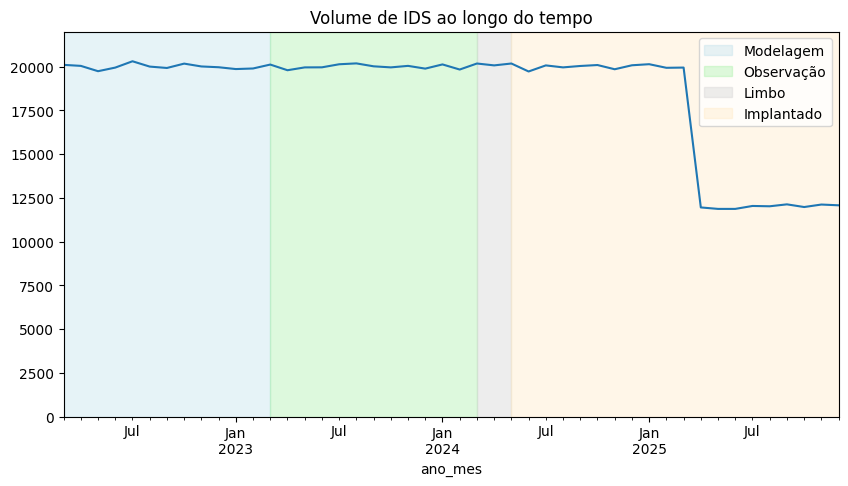

In [ ]:
contratos_tempo = base.groupby('ano_mes')['id'].count().reset_index()
contratos_tempo.columns = ['ano_mes','IDS']

cont = contratos_tempo.plot(x='ano_mes', y='IDS', figsize=(10,5))

# pintar fundo dos períodos
cont.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)
cont.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)
cont.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)
cont.axvspan('2024-05-01', contratos_tempo['ano_mes'].max(), color='moccasin', alpha=0.3)
# cont.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)
#cont.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)

# criar legenda das cores
modelagem = mpatches.Patch(color='lightblue', alpha=0.3, label='Modelagem')
observacao = mpatches.Patch(color='lightgreen', alpha=0.3, label='Observação')
limbo = mpatches.Patch(color='lightgray', alpha=0.4, label='Limbo')
implantado = mpatches.Patch(color='moccasin', alpha=0.3, label='Implantado')

plt.legend(handles=[modelagem, observacao, limbo, implantado])

plt.title('Volume de IDS ao longo do tempo')
plt.ylim(0,22000)

plt.show()

In [ ]:
antes = contratos_tempo[
    (contratos_tempo["ano_mes"] < "2025-03-01")
]["IDS"].mean()

depois = contratos_tempo[
    contratos_tempo["ano_mes"] >= "2025-03-01"
]["IDS"].mean()

queda = (antes - depois) / antes * 100

print(f"Média até 03/25: {antes:.2f}")
print(f"Média a partir de 03/25: {depois:.2f}")
print(f"Queda percentual: {queda:.2f}%")

Média até 03/25: 20001.69
Média a partir de 03/25: 12794.00
Queda percentual: 36.04%


Volume de IDS ao longo do tempo: é possível perceber que o volume mensal tem uma queda a partir de 2025/03, representando uma queda de registros nos meses posteriores.

*Por qual motivo isso aconteceu?*

# **AUSENTES**

*Aproximadamente 22.7% da base possui valores ausentes nas colunas target e FPD*

In [ ]:
# Percentual de valores ausentes para cada variável
base.isna().sum()/base.shape[0] * 100

,0
id,0.0
ano_mes,0.0
idade_veiculo,0.0
marca,0.0
vl_bem,0.0
idade,0.0
estado_civil,0.0
qt_restr,0.0
renda,0.0
Regiao,0.0


Conferindo se há valores ausentes, foi possível detectar que ~22.7% da base possui valores ausentes nas colunas target e FPD.

# **VARIÁVEL TARGET**
tipo: dicotômica

descrição: Se o contrato foi inadimplente (1) ou não (0).
           Se estiver vazio é porque o contrato não foi efetivado.

*No final não teve tempo ainda de saber se inadimpliu? Por isso temos tudo em 0 a partir de Janeiro?*

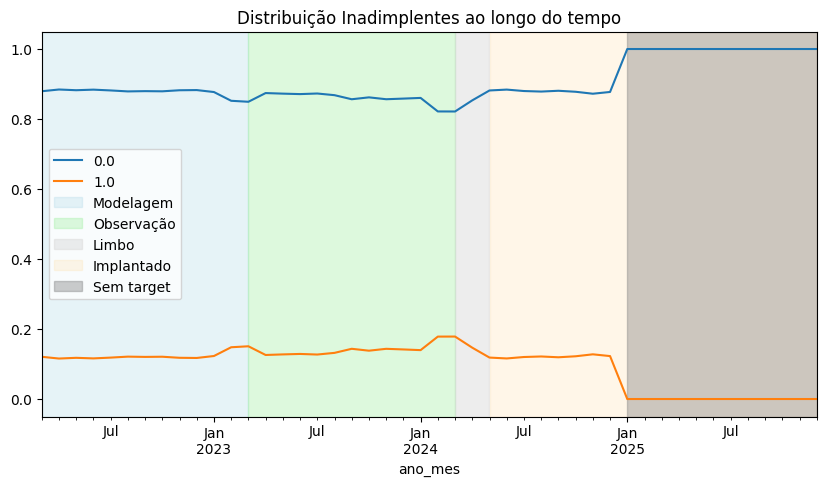

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['target'], normalize='index')

target = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
target.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)
target.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)
target.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)
target.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)
target.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)

# patches das áreas
modelagem = mpatches.Patch(color='lightblue', alpha=0.3, label='Modelagem')
observacao = mpatches.Patch(color='lightgreen', alpha=0.3, label='Observação')
limbo = mpatches.Patch(color='lightgray', alpha=0.4, label='Limbo')
implantado = mpatches.Patch(color='moccasin', alpha=0.3, label='Implantado')
sem_target = mpatches.Patch(color='gray', alpha=0.4, label='Sem target')

# pegar legenda das linhas
handles, labels = target.get_legend_handles_labels()

# juntar tudo
handles = handles + [modelagem, observacao, limbo, implantado, sem_target]
labels = labels + ['Modelagem', 'Observação', 'Limbo', 'Implantado', 'Sem target']

target.legend(handles, labels)

plt.title('Distribuição Inadimplentes ao longo do tempo')

plt.show()

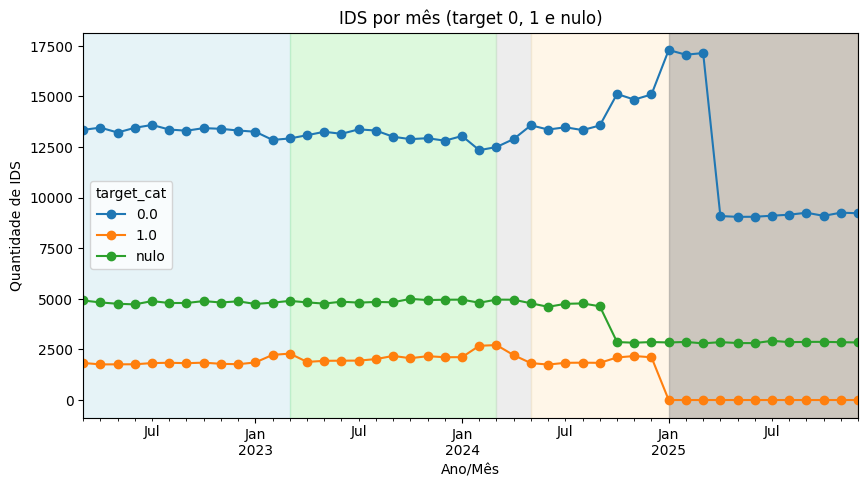

In [ ]:
tabela = (
    base
    .assign(target_cat = base['target'].fillna('nulo'))
    .groupby(['ano_mes','target_cat'])['id']
    .count()
    .unstack(fill_value=0)
)

ax = tabela.plot(figsize=(10,5), marker='o')

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
ax.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3) # implantado
ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('IDS por mês (target 0, 1 e nulo)')
plt.xlabel('Ano/Mês')
plt.ylabel('Quantidade de IDS')

plt.show()

# **VARIÁVEL CONTRATADO**

tipo: dicotômica

descrição: se a proposta foi efetivada (virou contrato) ou não

In [ ]:
base['contratado'].unique()

array([1, 0])

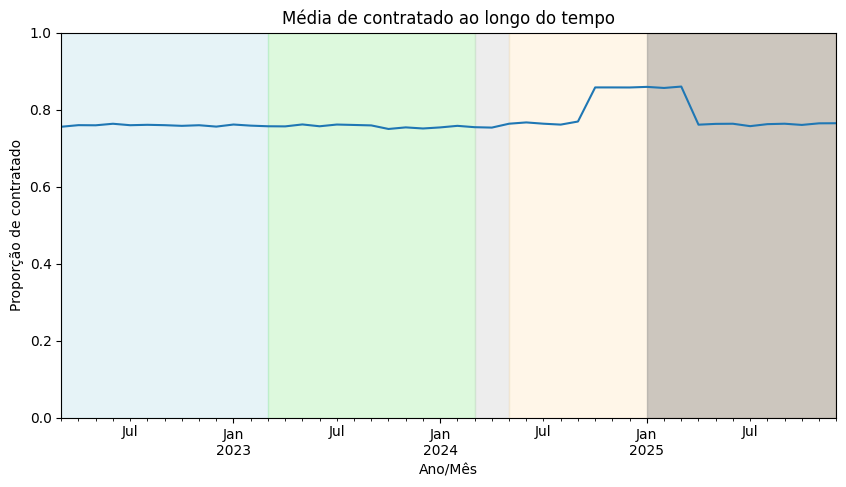

In [ ]:
cont_tempo = base.groupby('ano_mes')['contratado'].mean()

cont = cont_tempo.plot(figsize=(10,5))

# pintar fundo dos períodos
cont.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
cont.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
cont.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
cont.axvspan('2024-05-01', cont_tempo.index.max(), color='moccasin', alpha=0.3)  # implantado
#cont.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
cont.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('Média de contratado ao longo do tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('Proporção de contratado')
plt.ylim(0,1)

plt.show()

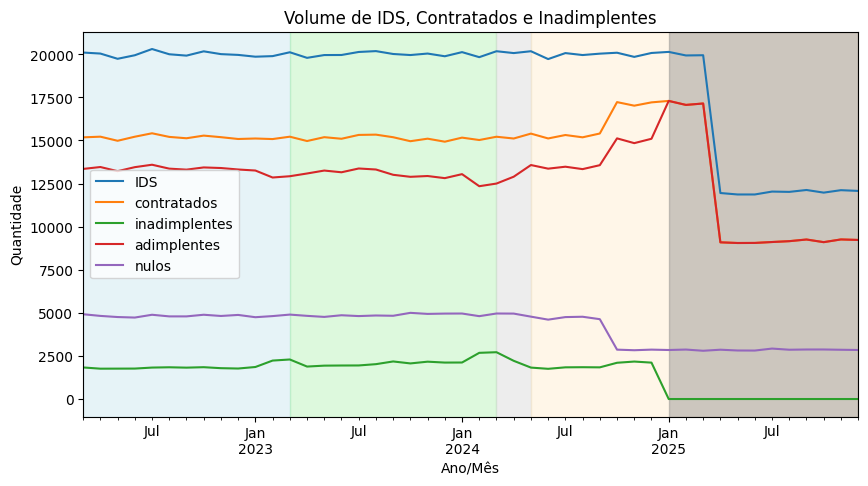

In [ ]:
tabela = (
    base.groupby('ano_mes')
    .agg(
        IDS=('id','count'),
        contratados=('contratado','sum'),
        inadimplentes=('target', lambda x: (x==1).sum()),
        adimplentes=('target', lambda x: (x==0).sum()),
        nulos=('target', lambda x: x.isna().sum())
    )
)

ax = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)
ax.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)
ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)

plt.title('Volume de IDS, Contratados e Inadimplentes')
plt.xlabel('Ano/Mês')
plt.ylabel('Quantidade')

plt.show()


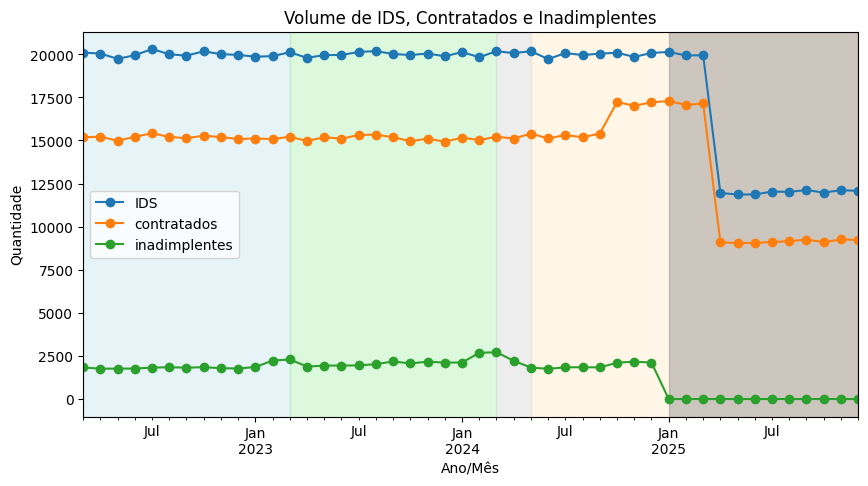

              IDS  aumento_IDS  crescimento_IDS_pct
ano_mes                                            
2022-03-01  20095          NaN                  NaN
2022-04-01  20037        -58.0            -0.288629
2022-05-01  19733       -304.0            -1.517193
2022-06-01  19939        206.0             1.043937
2022-07-01  20300        361.0             1.810522
2022-08-01  19996       -304.0            -1.497537
2022-09-01  19917        -79.0            -0.395079
2022-10-01  20166        249.0             1.250188
2022-11-01  20004       -162.0            -0.803332
2022-12-01  19959        -45.0            -0.224955
2023-01-01  19855       -104.0            -0.521068
2023-02-01  19888         33.0             0.166205
2023-03-01  20112        224.0             1.126307
2023-04-01  19788       -324.0            -1.610979
2023-05-01  19950        162.0             0.818678
2023-06-01  19954          4.0             0.020050
2023-07-01  20129        175.0             0.877017
2023-08-01  

In [ ]:
# tabela com métricas
tabela = (
    base.groupby('ano_mes')
    .agg(
        IDS=('id','count'),
        contratados=('contratado','sum'),
        inadimplentes=('target', lambda x: (x==1).sum())
    )
)

# crescimento IDS
tabela['aumento_IDS'] = tabela['IDS'].diff()
tabela['crescimento_IDS_pct'] = tabela['IDS'].pct_change()*100

# crescimento contratos
tabela['aumento_contratos'] = tabela['contratados'].diff()
tabela['crescimento_contratos_pct'] = tabela['contratados'].pct_change()*100

# crescimento inadimplentes
tabela['aumento_inad'] = tabela['inadimplentes'].diff()
tabela['crescimento_inad_pct'] = tabela['inadimplentes'].pct_change()*100

# gráfico
ax = tabela[['IDS','contratados','inadimplentes']].plot(figsize=(10,5), marker='o')

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)
ax.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)
ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)

plt.title('Volume de IDS, Contratados e Inadimplentes')
plt.xlabel('Ano/Mês')
plt.ylabel('Quantidade')

plt.show()

print(tabela[['IDS','aumento_IDS','crescimento_IDS_pct']])

print(tabela[['contratados','aumento_contratos','crescimento_contratos_pct']])

print(tabela[['inadimplentes','aumento_inad','crescimento_inad_pct']])




# **VARIÁVEL IDADE DO VEÍCULO**

tipo: categórica

descrição: idade do veículo a ser financiado

*É estavel e baixo poder de predição.*

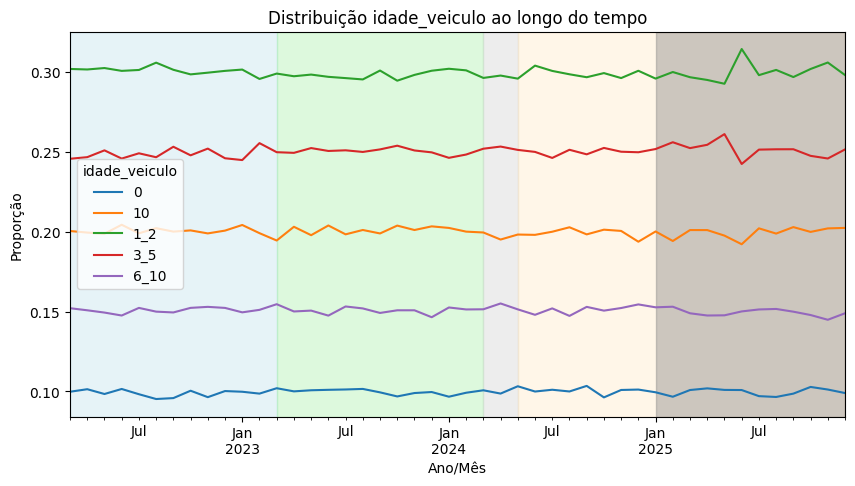

In [ ]:
base["ano_mes"] = pd.to_datetime(base["ano_mes"])

tabela = pd.crosstab(base['ano_mes'], base['idade_veiculo'], normalize='index')

id_veiculo = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
id_veiculo.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
id_veiculo.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
id_veiculo.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
id_veiculo.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)  # implantado
#id_veiculo.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
id_veiculo.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('Distribuição idade_veiculo ao longo do tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('Proporção')

plt.show()

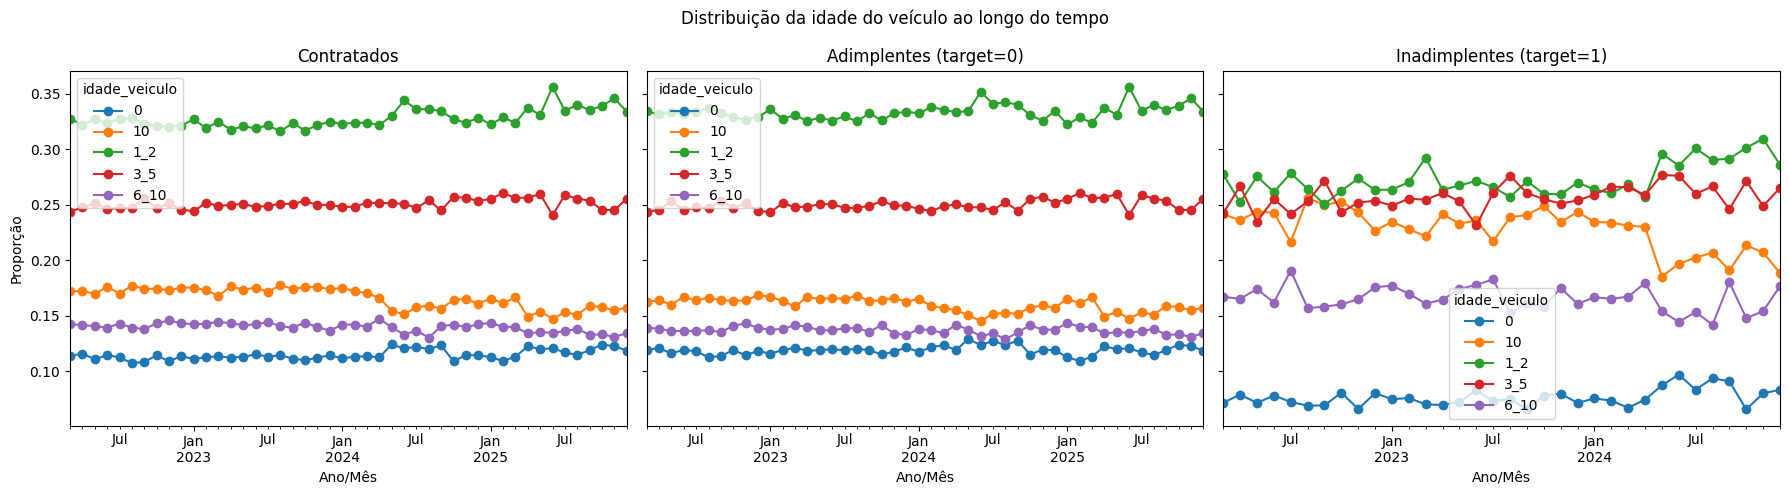

In [ ]:
# separar grupos
df_contratado = base[base['contratado'] == 1]
df_adimplente = base[base['target'] == 0]
df_inadimplente = base[base['target'] == 1]

# criar tabelas de distribuição
tab_contratado = pd.crosstab(
    df_contratado['ano_mes'],
    df_contratado['idade_veiculo'],
    normalize='index'
)

tab_adimplente = pd.crosstab(
    df_adimplente['ano_mes'],
    df_adimplente['idade_veiculo'],
    normalize='index'
)

tab_inadimplente = pd.crosstab(
    df_inadimplente['ano_mes'],
    df_inadimplente['idade_veiculo'],
    normalize='index'
)

# criar gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Distribuição da idade do veículo ao longo do tempo')
plt.tight_layout()

plt.show()

A idade do veiculo não diferente quem contrata e paga.

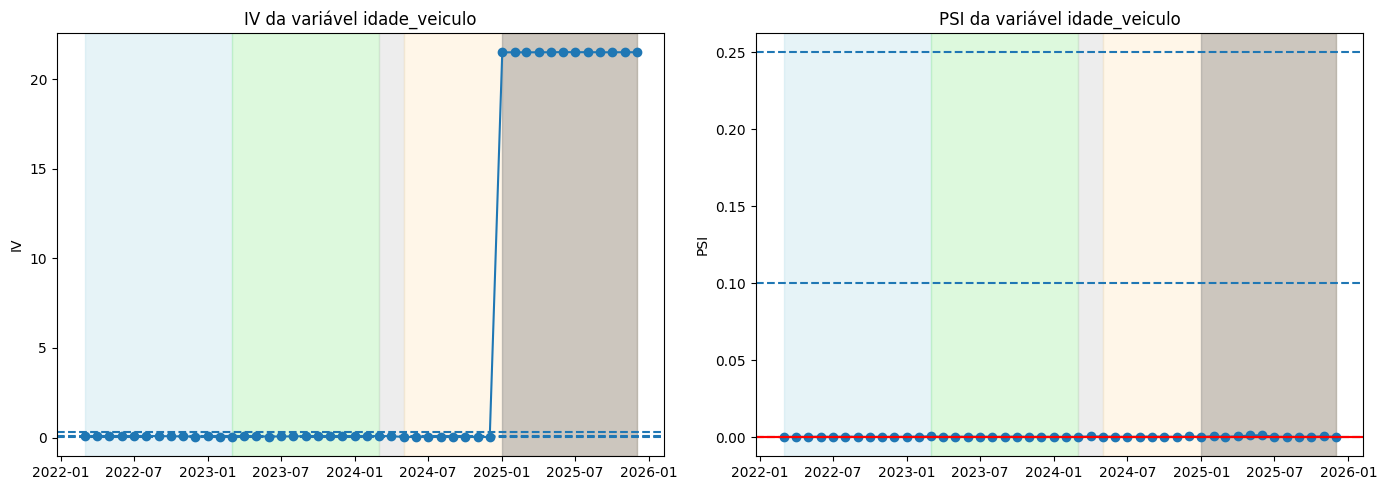

In [ ]:
variavel = 'idade_veiculo'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

# tentar converter para numérico
try:
    df[variavel] = pd.to_numeric(df[variavel])
except:
    pass

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
]

# bins para PSI
if np.issubdtype(df[variavel].dtype, np.number):
    bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories
else:
    bins = base_modelagem[variavel].astype(str).unique()

iv_lista = []
psi_lista = []
meses = []

for mes, dados in df.groupby('ano_mes'):

    meses.append(mes)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados[variavel], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))

    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    if np.issubdtype(df[variavel].dtype, np.number):

        base_counts = pd.cut(base_modelagem[variavel], bins).value_counts(normalize=True)
        atual_counts = pd.cut(dados[variavel], bins).value_counts(normalize=True)

    else:

        base_counts = base_modelagem[variavel].value_counts(normalize=True)
        atual_counts = dados[variavel].value_counts(normalize=True)

    base_counts, atual_counts = base_counts.align(atual_counts, fill_value=0.0001)

    psi = ((base_counts-atual_counts)*np.log((base_counts+1e-10)/(atual_counts+1e-10))).sum()

    psi_lista.append(psi)

# dataframe final
result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS LADO A LADO
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title("IV da variável idade_veiculo")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title("PSI da variável idade_veiculo")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.tight_layout()
plt.show()


PSI: variável estável.

IV: variável fraca preditivamente (reafirmando o cenário anterior de inadimplencia).

# **VARIÁVEL MARCA**

tipo: categórica

descrição: marca do veículo a ser financiado

*Não é estável e baixo poder de predição.*

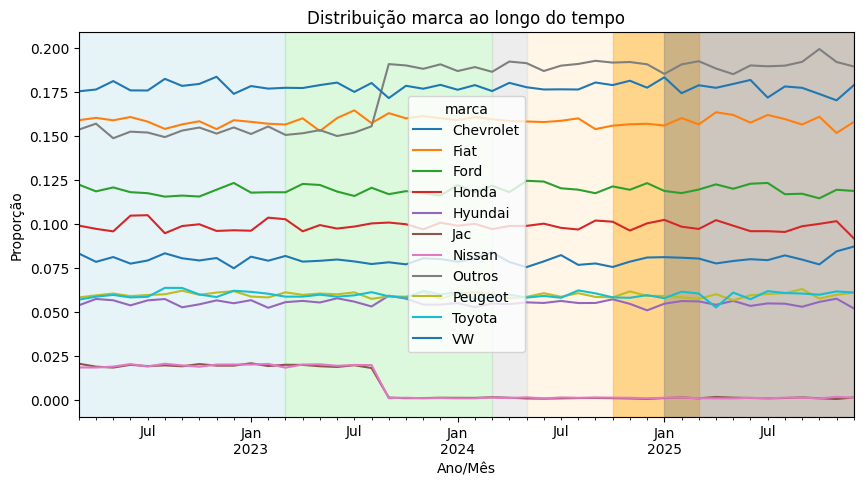

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['marca'], normalize='index')

marca = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
marca.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
marca.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
marca.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
marca.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)  # implantado
marca.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
marca.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('Distribuição marca ao longo do tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('Proporção')

plt.show()

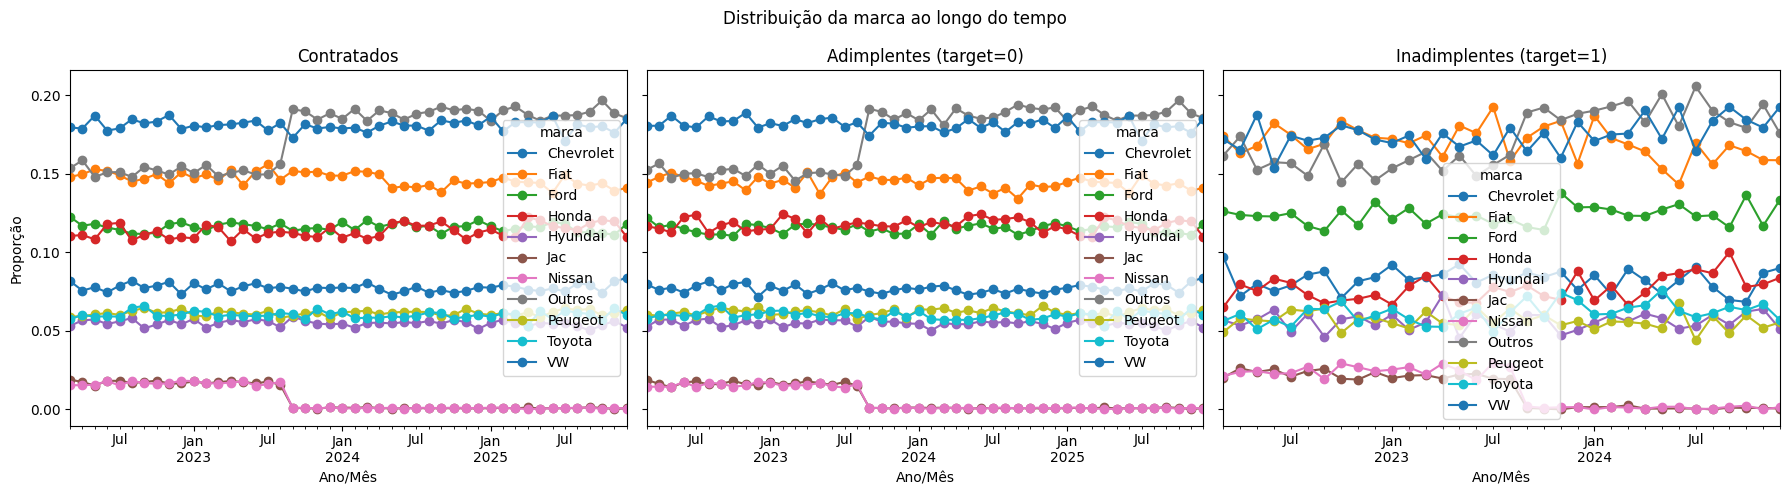

In [ ]:
# separar grupos
df_contratado = base[base['contratado'] == 1]
df_adimplente = base[base['target'] == 0]
df_inadimplente = base[base['target'] == 1]

# criar tabelas de distribuição
tab_contratado = pd.crosstab(
    df_contratado['ano_mes'],
    df_contratado['marca'],
    normalize='index'
)

tab_adimplente = pd.crosstab(
    df_adimplente['ano_mes'],
    df_adimplente['marca'],
    normalize='index'
)

tab_inadimplente = pd.crosstab(
    df_inadimplente['ano_mes'],
    df_inadimplente['marca'],
    normalize='index'
)

# criar gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Distribuição da marca ao longo do tempo')
plt.tight_layout()

plt.show()

A marca não diferente quem contrata e paga.

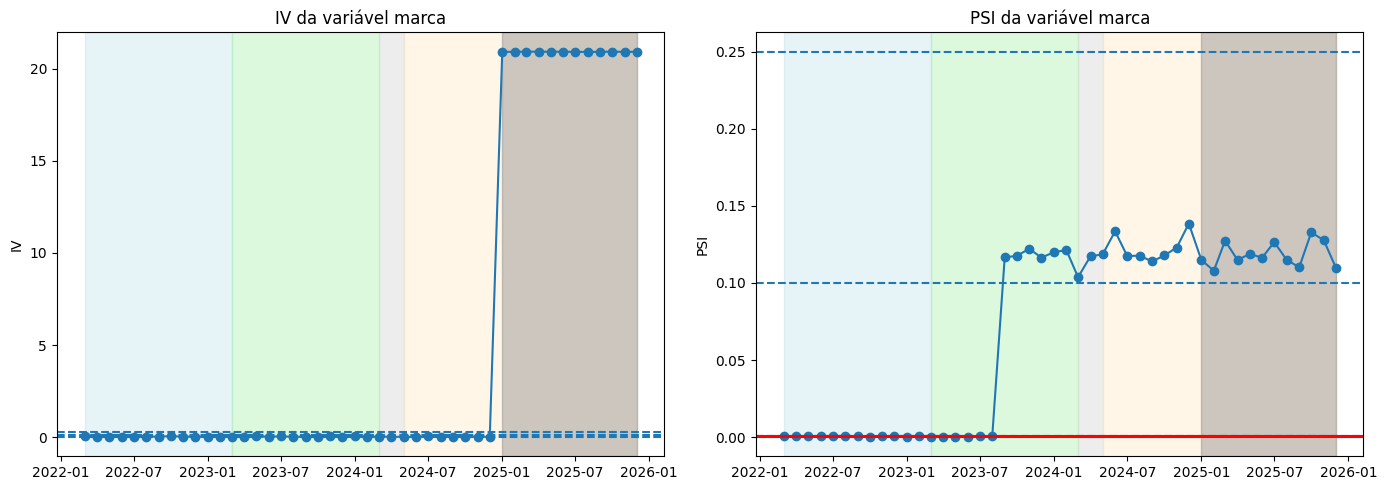

In [ ]:
variavel = 'marca'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

# tentar converter para numérico
try:
    df[variavel] = pd.to_numeric(df[variavel])
except:
    pass

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
]

# bins para PSI
if np.issubdtype(df[variavel].dtype, np.number):
    bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories
else:
    bins = base_modelagem[variavel].astype(str).unique()

iv_lista = []
psi_lista = []
meses = []

for mes, dados in df.groupby('ano_mes'):

    meses.append(mes)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados[variavel], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))

    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    if np.issubdtype(df[variavel].dtype, np.number):

        base_counts = pd.cut(base_modelagem[variavel], bins).value_counts(normalize=True)
        atual_counts = pd.cut(dados[variavel], bins).value_counts(normalize=True)

    else:

        base_counts = base_modelagem[variavel].value_counts(normalize=True)
        atual_counts = dados[variavel].value_counts(normalize=True)

    base_counts, atual_counts = base_counts.align(atual_counts, fill_value=0.0001)

    psi = ((base_counts-atual_counts)*np.log((base_counts+1e-10)/(atual_counts+1e-10))).sum()

    psi_lista.append(psi)

# dataframe final
result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS LADO A LADO
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title("IV da variável marca")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title("PSI da variável marca")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.tight_layout()
plt.show()

PSI aumentou: O perfil de veículos mudou.

IV continua ≈ 0: Mesmo mudando o perfil, a variável continua não separando risco.

# **VARIÁVEL VALOR DO BEM**

tipo: categórica

descrição: valor do veículo a ser financiado

Erro de base em uma categoria - 25a70?

*É estável e baixo poder de predição.*

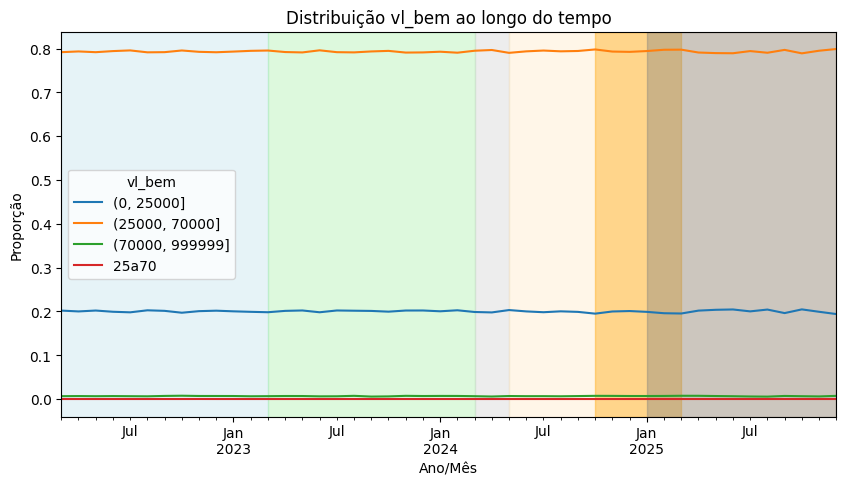

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['vl_bem'], normalize='index')

vl_bem = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
vl_bem.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
vl_bem.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
vl_bem.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
vl_bem.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)  # implantado
vl_bem.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
vl_bem.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('Distribuição vl_bem ao longo do tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('Proporção')

plt.show()

In [ ]:
base['vl_bem'].value_counts()

,count
vl_bem,
"(25000, 70000]",672748
"(0, 25000]",169590
"(70000, 999999]",5662
25a70,1


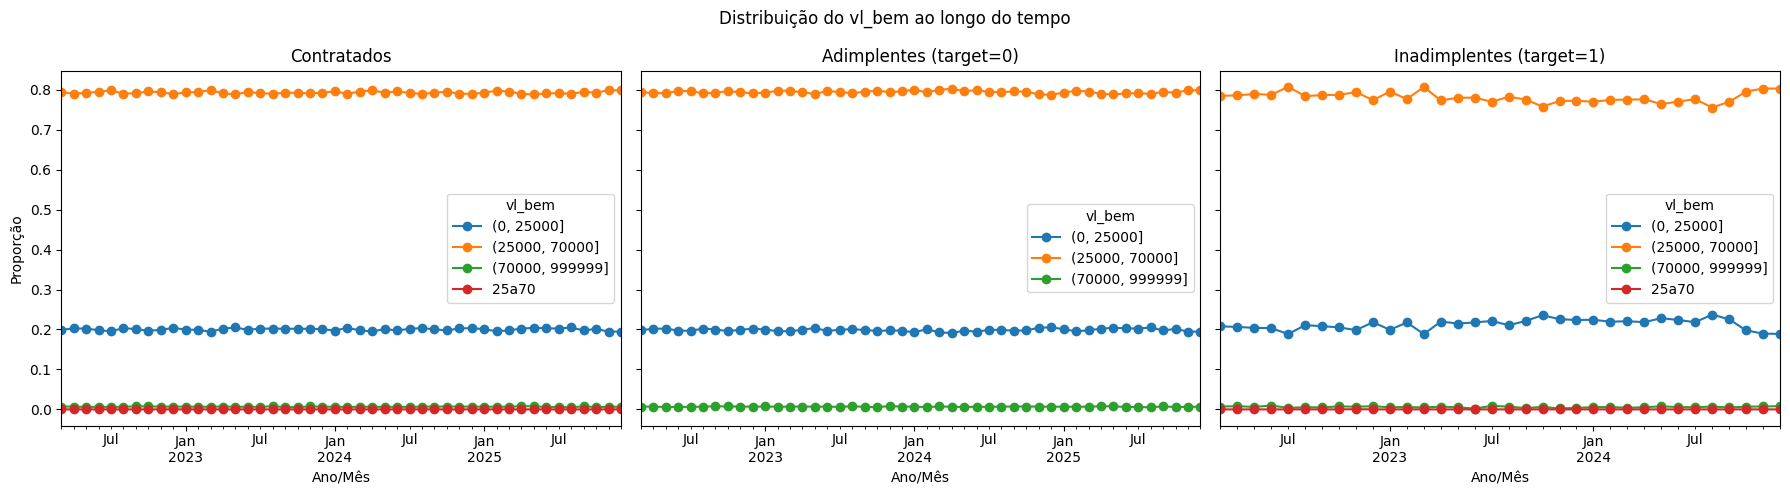

In [ ]:
# separar grupos
df_contratado = base[base['contratado'] == 1]
df_adimplente = base[base['target'] == 0]
df_inadimplente = base[base['target'] == 1]

# criar tabelas de distribuição
tab_contratado = pd.crosstab(
    df_contratado['ano_mes'],
    df_contratado['vl_bem'],
    normalize='index'
)

tab_adimplente = pd.crosstab(
    df_adimplente['ano_mes'],
    df_adimplente['vl_bem'],
    normalize='index'
)

tab_inadimplente = pd.crosstab(
    df_inadimplente['ano_mes'],
    df_inadimplente['vl_bem'],
    normalize='index'
)

# criar gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Distribuição do vl_bem ao longo do tempo')
plt.tight_layout()

plt.show()

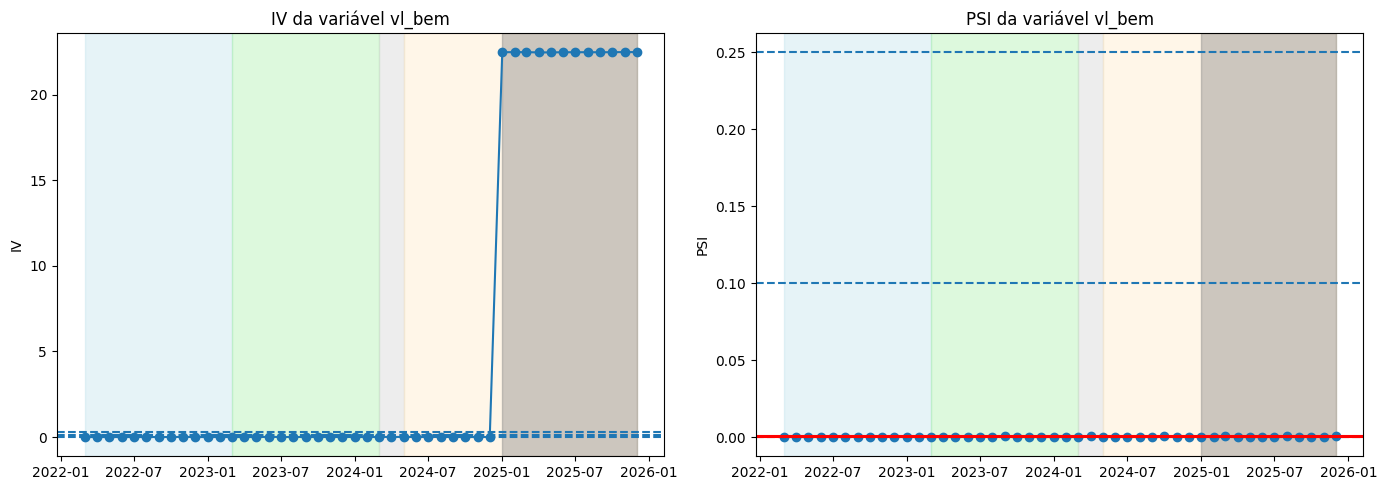

In [ ]:
variavel = 'vl_bem'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

# tentar converter para numérico
try:
    df[variavel] = pd.to_numeric(df[variavel])
except:
    pass

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
]

# bins para PSI
if np.issubdtype(df[variavel].dtype, np.number):
    bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories
else:
    bins = base_modelagem[variavel].astype(str).unique()

iv_lista = []
psi_lista = []
meses = []

for mes, dados in df.groupby('ano_mes'):

    meses.append(mes)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados[variavel], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))

    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    if np.issubdtype(df[variavel].dtype, np.number):

        base_counts = pd.cut(base_modelagem[variavel], bins).value_counts(normalize=True)
        atual_counts = pd.cut(dados[variavel], bins).value_counts(normalize=True)

    else:

        base_counts = base_modelagem[variavel].value_counts(normalize=True)
        atual_counts = dados[variavel].value_counts(normalize=True)

    base_counts, atual_counts = base_counts.align(atual_counts, fill_value=0.0001)

    psi = ((base_counts-atual_counts)*np.log((base_counts+1e-10)/(atual_counts+1e-10))).sum()

    psi_lista.append(psi)

# dataframe final
result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS LADO A LADO
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title("IV da variável vl_bem")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title("PSI da variável vl_bem")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.tight_layout()
plt.show()

# **VARIÁVEL IDADE**

tipo:contínua

descrição: idade do proponente

*É estável e baixo poder de predição.*

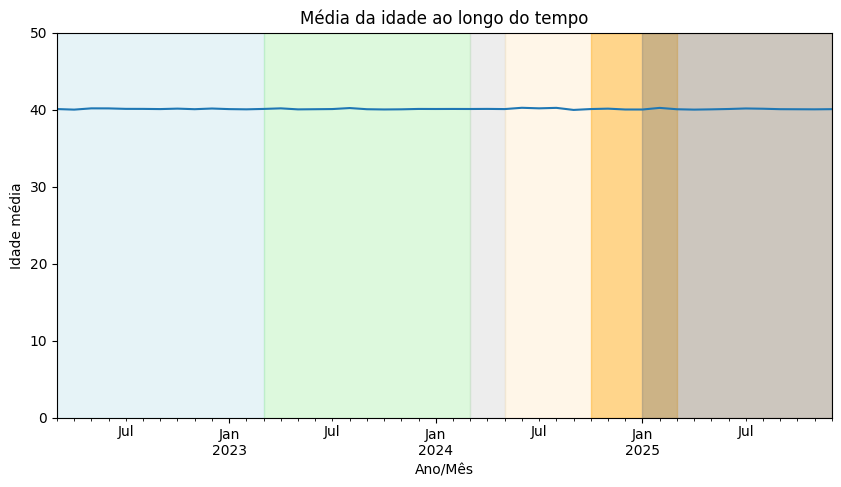

In [ ]:
idade_tempo = base.groupby('ano_mes')['idade'].mean()

idade = idade_tempo.plot(figsize=(10,5))

# pintar fundo dos períodos
idade.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
idade.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
idade.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
idade.axvspan('2024-05-01', idade_tempo.index.max(), color='moccasin', alpha=0.3)  # implantado
idade.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
idade.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('Média da idade ao longo do tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('Idade média')
plt.ylim(0,50)

plt.show()

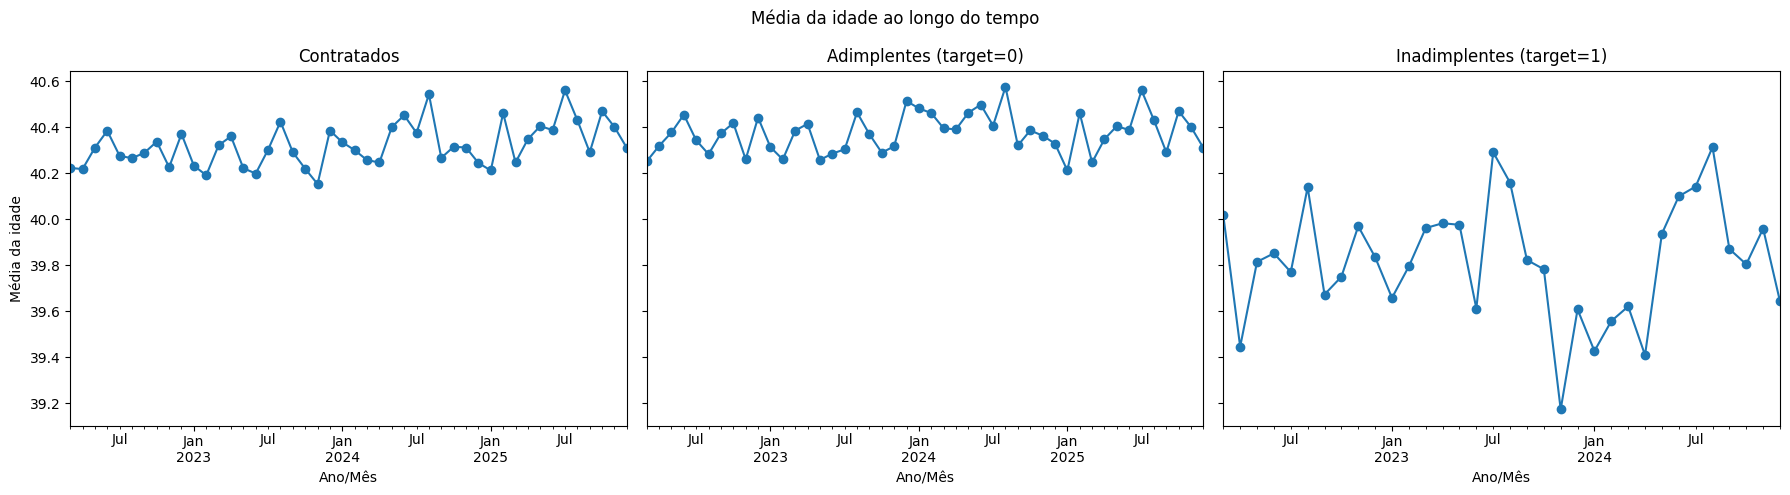

In [ ]:
# média do valor do bem por mês
tab_contratado = df_contratado.groupby('ano_mes')['idade'].mean()
tab_adimplente = df_adimplente.groupby('ano_mes')['idade'].mean()
tab_inadimplente = df_inadimplente.groupby('ano_mes')['idade'].mean()

# gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Média da idade')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Média da idade ao longo do tempo')

plt.tight_layout()
plt.show()


Quem paga tem praticamente a mesma idade média de quem é aprovado.

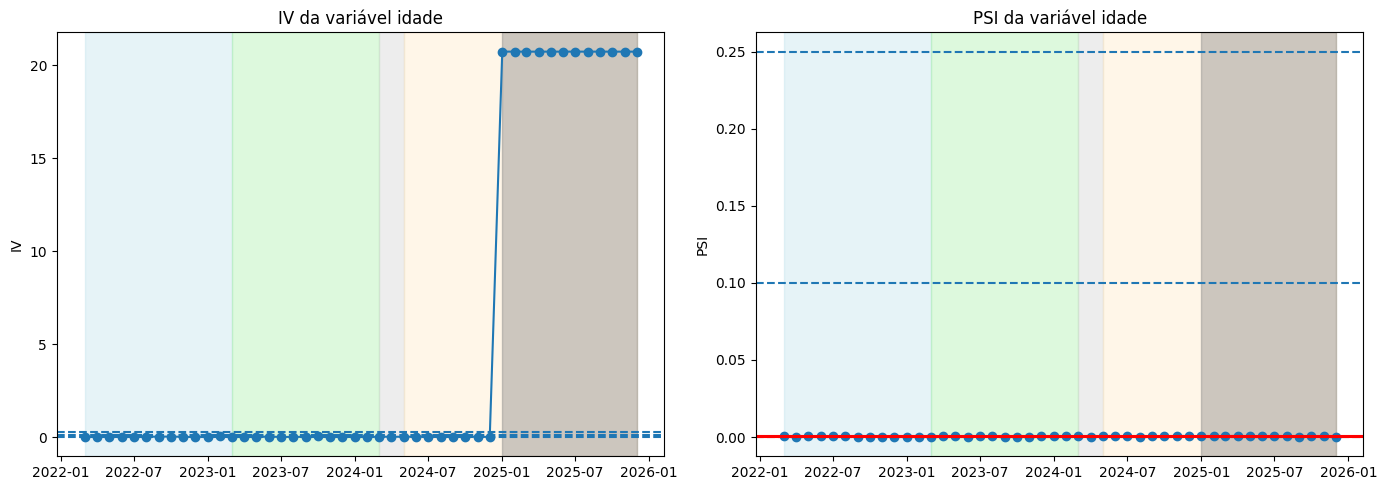

In [ ]:
variavel = 'idade'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])
df[variavel] = pd.to_numeric(df[variavel], errors='coerce')

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
].copy()

# criar bins usando apenas a base de modelagem
bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories

iv_lista = []
psi_lista = []
meses = []

# distribuição da base (para PSI)
base_modelagem['bin'] = pd.cut(base_modelagem[variavel], bins)
base_dist = base_modelagem['bin'].value_counts(normalize=True)

# ---------------------------
# LOOP POR MÊS
# ---------------------------

for mes, dados in df.groupby('ano_mes'):

    dados = dados.copy()
    meses.append(mes)

    dados['bin'] = pd.cut(dados[variavel], bins)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados['bin'], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))
    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    atual_dist = dados['bin'].value_counts(normalize=True)

    base_aligned, atual_aligned = base_dist.align(atual_dist, fill_value=0.0001)

    psi = ((base_aligned-atual_aligned) *
           np.log((base_aligned+1e-10)/(atual_aligned+1e-10))).sum()

    psi_lista.append(psi)

# ---------------------------
# RESULTADO FINAL
# ---------------------------

result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title(f"IV da variável {variavel}")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title(f"PSI da variável {variavel}")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01','2025-12-01',color='gray',alpha=0.4)

plt.tight_layout()
plt.show()


# **VARIÁVEL ESTADO CIVIL**
tipo:categórica

descrição: estado civil do proponente

*É estável e baixo poder de predição.*

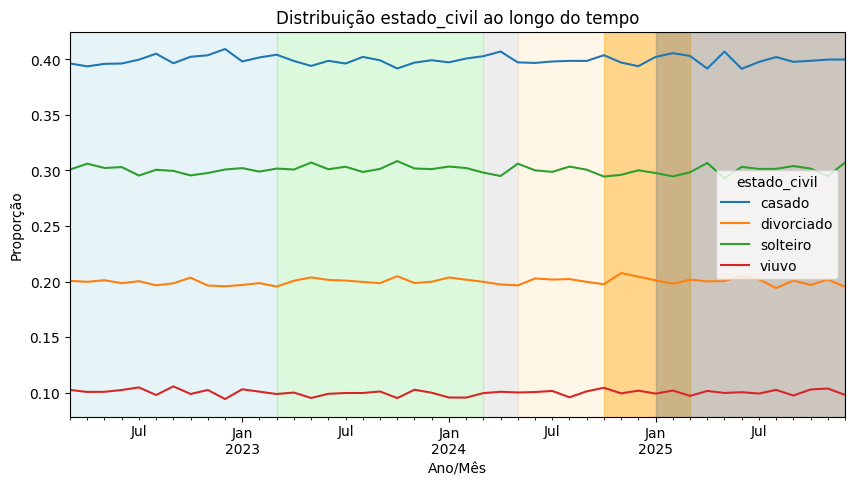

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['estado_civil'], normalize='index')

estado_civil = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
estado_civil.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
estado_civil.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
estado_civil.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
estado_civil.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)  # implantado
estado_civil.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
estado_civil.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('Distribuição estado_civil ao longo do tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('Proporção')

plt.show()

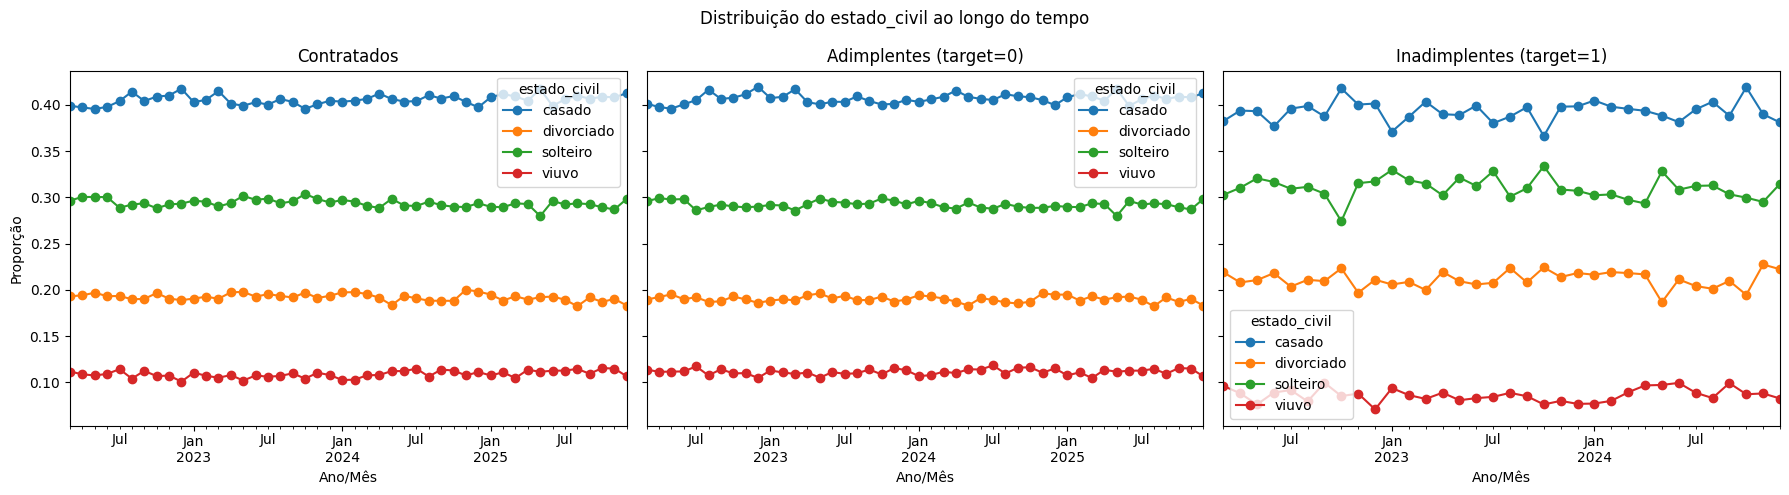

In [ ]:
# separar grupos
df_contratado = base[base['contratado'] == 1]
df_adimplente = base[base['target'] == 0]
df_inadimplente = base[base['target'] == 1]

# criar tabelas de distribuição
tab_contratado = pd.crosstab(
    df_contratado['ano_mes'],
    df_contratado['estado_civil'],
    normalize='index'
)

tab_adimplente = pd.crosstab(
    df_adimplente['ano_mes'],
    df_adimplente['estado_civil'],
    normalize='index'
)

tab_inadimplente = pd.crosstab(
    df_inadimplente['ano_mes'],
    df_inadimplente['estado_civil'],
    normalize='index'
)

# criar gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Distribuição do estado_civil ao longo do tempo')
plt.tight_layout()

plt.show()

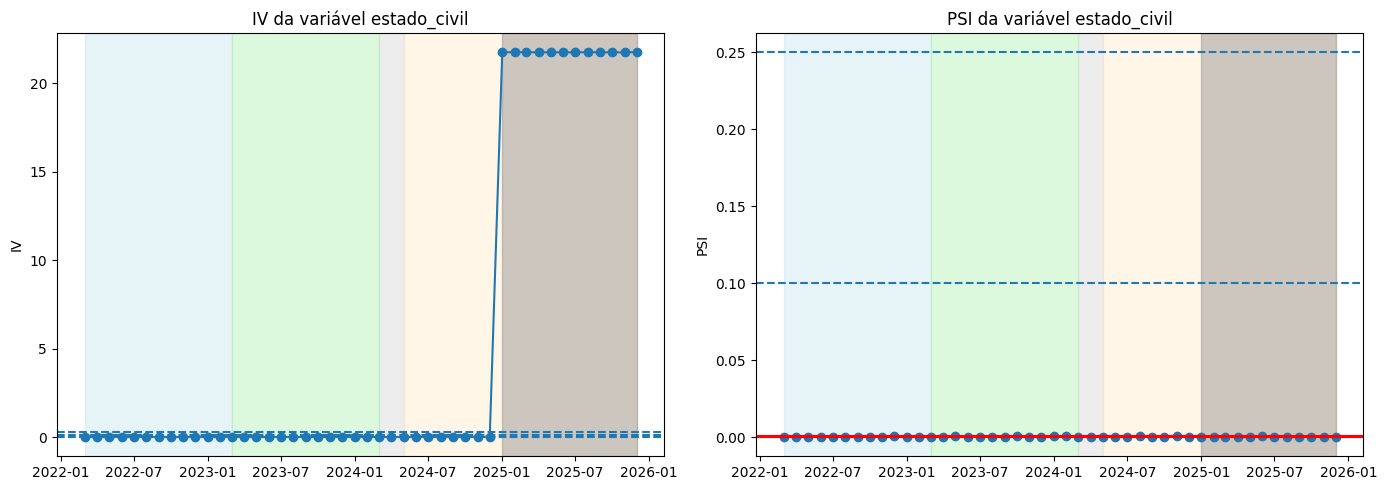

In [ ]:
variavel = 'estado_civil'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

# tentar converter para numérico
try:
    df[variavel] = pd.to_numeric(df[variavel])
except:
    pass

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
]

# bins para PSI
if np.issubdtype(df[variavel].dtype, np.number):
    bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories
else:
    bins = base_modelagem[variavel].astype(str).unique()

iv_lista = []
psi_lista = []
meses = []

for mes, dados in df.groupby('ano_mes'):

    meses.append(mes)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados[variavel], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))

    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    if np.issubdtype(df[variavel].dtype, np.number):

        base_counts = pd.cut(base_modelagem[variavel], bins).value_counts(normalize=True)
        atual_counts = pd.cut(dados[variavel], bins).value_counts(normalize=True)

    else:

        base_counts = base_modelagem[variavel].value_counts(normalize=True)
        atual_counts = dados[variavel].value_counts(normalize=True)

    base_counts, atual_counts = base_counts.align(atual_counts, fill_value=0.0001)

    psi = ((base_counts-atual_counts)*np.log((base_counts+1e-10)/(atual_counts+1e-10))).sum()

    psi_lista.append(psi)

# dataframe final
result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS LADO A LADO
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title("IV da variável estado_civil")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title("PSI da variável estado_civil")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.tight_layout()
plt.show()

# **VARIÁVEL RESTRIÇÃO**
tipo:categórica

descrição: quantidade de restritivos em aberto no mercado em nome do proponente

*Mudou a estabilidade e baixo poder de predição.*

Deu ruim entre OUT/24 a MAR/25

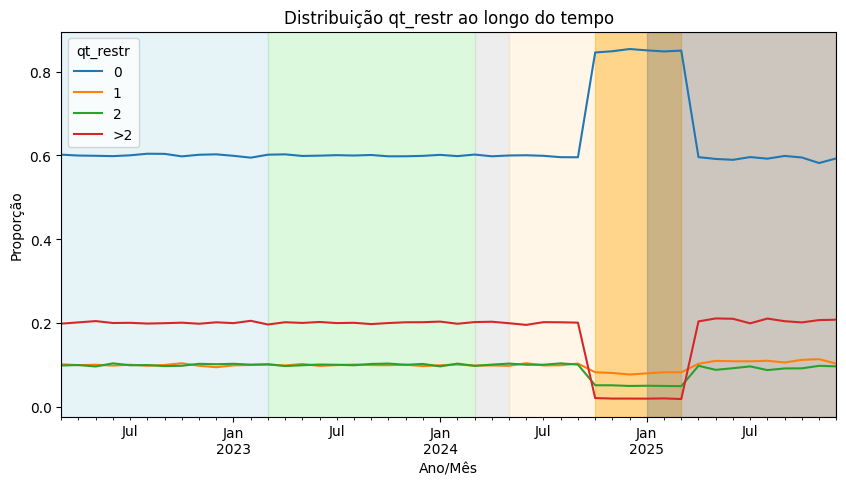

In [ ]:

tabela = pd.crosstab(base['ano_mes'], base['qt_restr'], normalize='index')

qt_restr = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
qt_restr.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
qt_restr.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
qt_restr.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
qt_restr.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)  # implantado
qt_restr.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
qt_restr.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('Distribuição qt_restr ao longo do tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('Proporção')

plt.show()

A variável qt_restr apresenta estabilidade ao longo da maior parte do período analisado. Entretanto, observa-se uma ruptura temporária na distribuição por volta de 2025, quando a proporção de clientes sem restrições aumenta significativamente, enquanto as demais categorias praticamente desaparecem. Esse comportamento pode indicar mudança na política de crédito ou inconsistência na captura da variável naquele período.

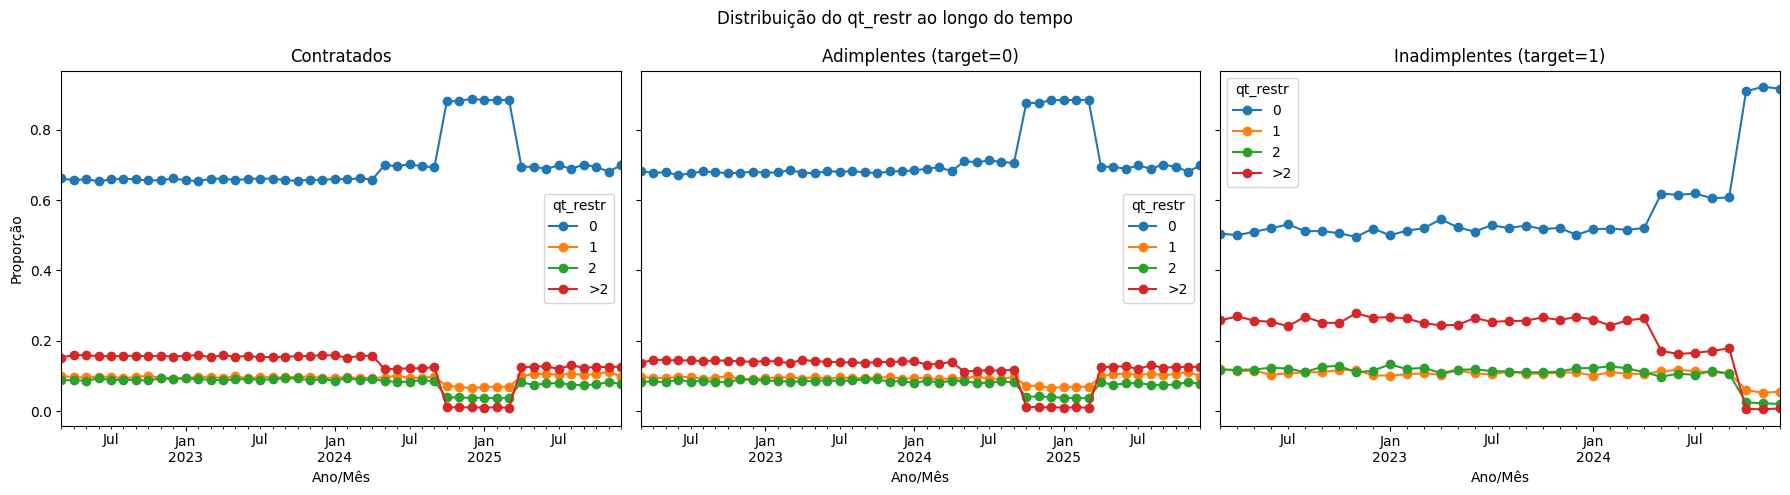

In [ ]:
# separar grupos
df_contratado = base[base['contratado'] == 1]
df_adimplente = base[base['target'] == 0]
df_inadimplente = base[base['target'] == 1]

# criar tabelas de distribuição
tab_contratado = pd.crosstab(
    df_contratado['ano_mes'],
    df_contratado['qt_restr'],
    normalize='index'
)

tab_adimplente = pd.crosstab(
    df_adimplente['ano_mes'],
    df_adimplente['qt_restr'],
    normalize='index'
)

tab_inadimplente = pd.crosstab(
    df_inadimplente['ano_mes'],
    df_inadimplente['qt_restr'],
    normalize='index'
)

# criar gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Distribuição do qt_restr ao longo do tempo')
plt.tight_layout()

plt.show()

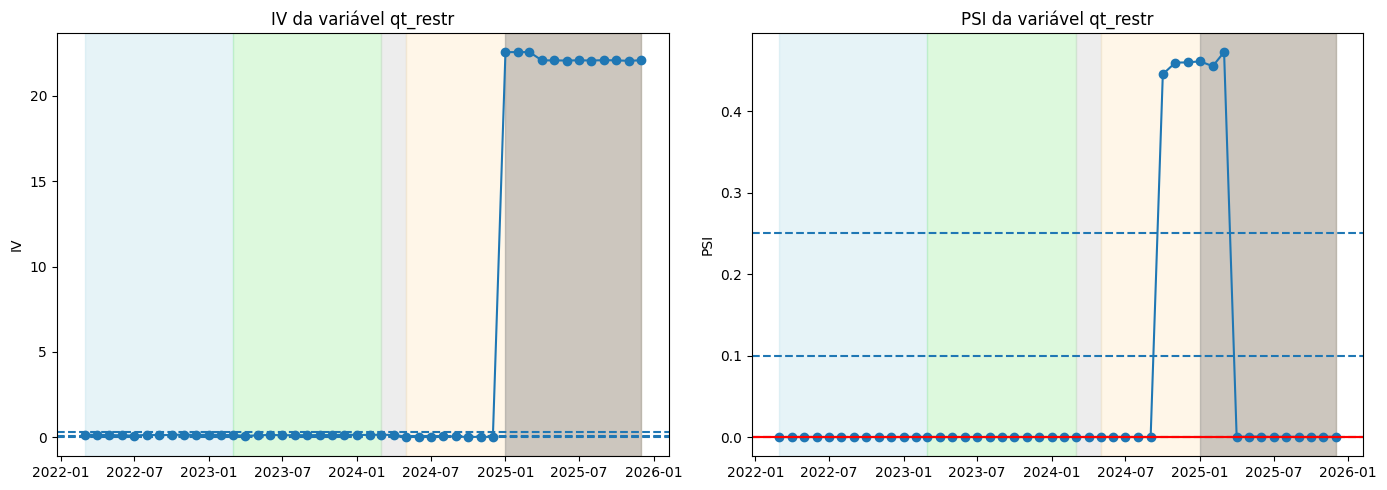

In [79]:
variavel = 'qt_restr'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

# tentar converter para numérico
try:
    df[variavel] = df[variavel].replace(">2",99)
    df[variavel] = pd.to_numeric(df[variavel])
except:
    pass

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
]

# bins para PSI
if np.issubdtype(df[variavel].dtype, np.number):
    bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories
else:
    bins = base_modelagem[variavel].astype(str).unique()

iv_lista = []
psi_lista = []
meses = []

for mes, dados in df.groupby('ano_mes'):

    meses.append(mes)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados[variavel], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))

    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    if np.issubdtype(df[variavel].dtype, np.number):

        base_counts = pd.cut(base_modelagem[variavel], bins).value_counts(normalize=True)
        atual_counts = pd.cut(dados[variavel], bins).value_counts(normalize=True)

    else:

        base_counts = base_modelagem[variavel].value_counts(normalize=True)
        atual_counts = dados[variavel].value_counts(normalize=True)

    base_counts, atual_counts = base_counts.align(atual_counts, fill_value=0.0001)

    psi = ((base_counts-atual_counts)*np.log((base_counts+1e-10)/(atual_counts+1e-10))).sum()

    psi_lista.append(psi)

# dataframe final
result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS LADO A LADO
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title("IV da variável qt_restr")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title("PSI da variável qt_restr")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.tight_layout()
plt.show()

# **VARIÁVEL RENDA**
tipo: contínua

descrição: renda do proponente

*É estável e baixo poder de predição.*

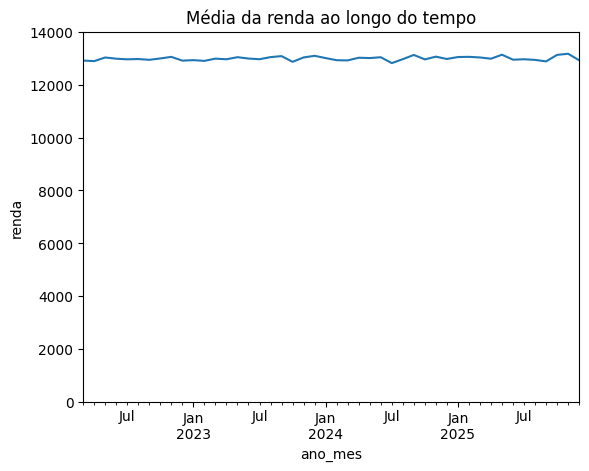

In [ ]:
renda_tempo = base.groupby('ano_mes')['renda'].mean()

renda_tempo.plot()
plt.title('Média da renda ao longo do tempo')
plt.xlabel('ano_mes')
plt.ylabel('renda')
plt.ylim(0,14000)
plt.show()

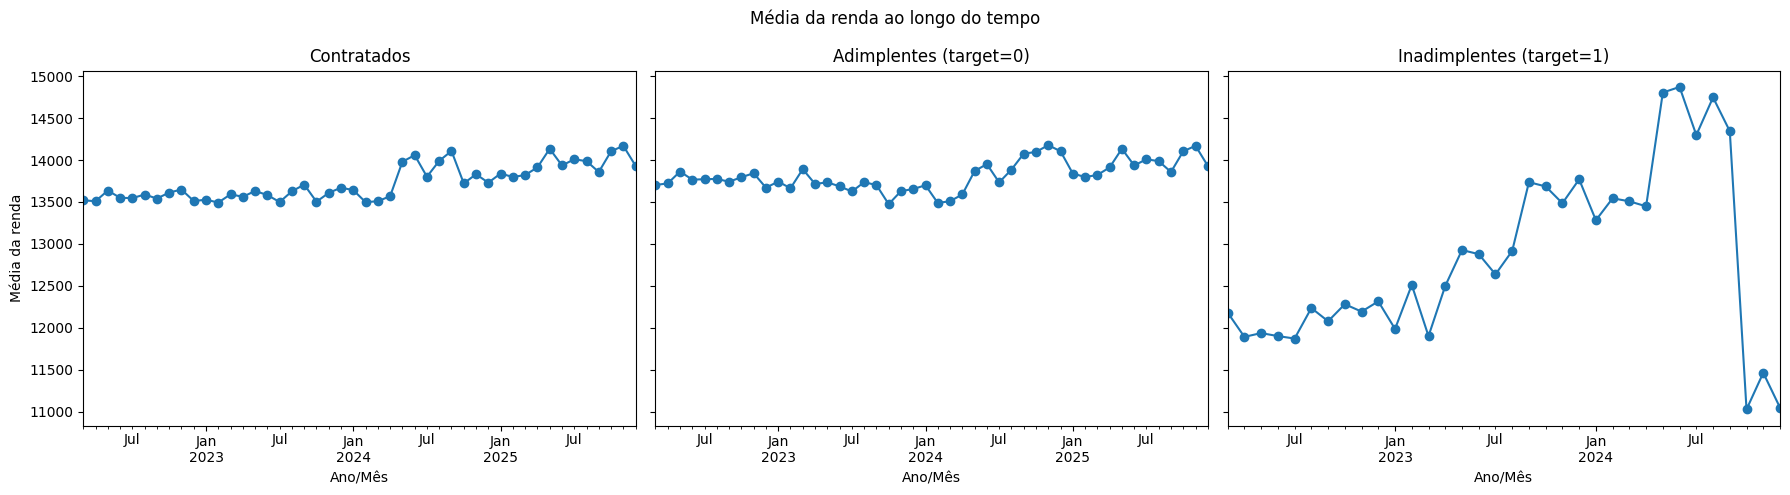

In [ ]:
# média do valor do bem por mês
tab_contratado = df_contratado.groupby('ano_mes')['renda'].mean()
tab_adimplente = df_adimplente.groupby('ano_mes')['renda'].mean()
tab_inadimplente = df_inadimplente.groupby('ano_mes')['renda'].mean()

# gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Média da renda')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Média da renda ao longo do tempo')

plt.tight_layout()
plt.show()


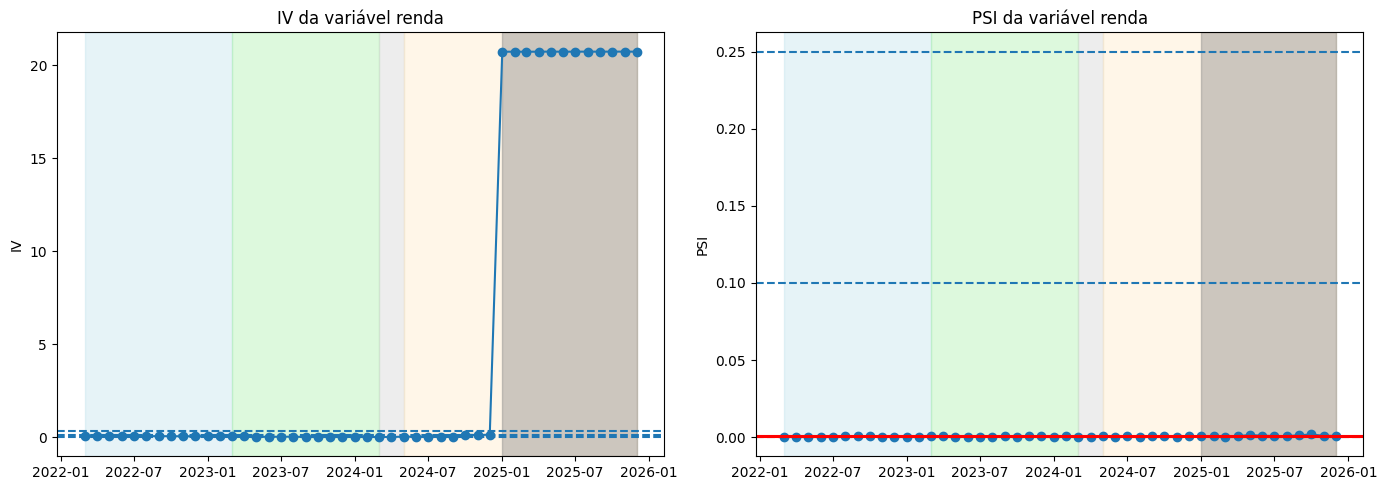

In [ ]:
variavel = 'renda'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])
df[variavel] = pd.to_numeric(df[variavel], errors='coerce')

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
].copy()

# criar bins usando apenas a base de modelagem
bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories

iv_lista = []
psi_lista = []
meses = []

# distribuição da base (para PSI)
base_modelagem['bin'] = pd.cut(base_modelagem[variavel], bins)
base_dist = base_modelagem['bin'].value_counts(normalize=True)

# ---------------------------
# LOOP POR MÊS
# ---------------------------

for mes, dados in df.groupby('ano_mes'):

    dados = dados.copy()
    meses.append(mes)

    dados['bin'] = pd.cut(dados[variavel], bins)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados['bin'], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))
    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    atual_dist = dados['bin'].value_counts(normalize=True)

    base_aligned, atual_aligned = base_dist.align(atual_dist, fill_value=0.0001)

    psi = ((base_aligned-atual_aligned) *
           np.log((base_aligned+1e-10)/(atual_aligned+1e-10))).sum()

    psi_lista.append(psi)

# ---------------------------
# RESULTADO FINAL
# ---------------------------

result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title(f"IV da variável {variavel}")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title(f"PSI da variável {variavel}")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01','2025-12-01',color='gray',alpha=0.4)

plt.tight_layout()
plt.show()

# **VARIÁVEL REGIÃO**
tipo: categórica

descrição: região de residencia do proponente

*Mudou a estabilidade e baixo poder de predição.*

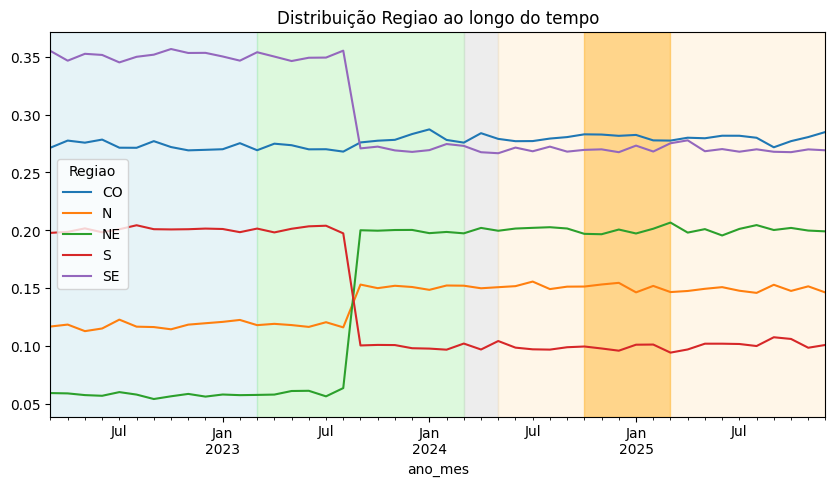

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['Regiao'], normalize='index')

ax = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3) # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3) # janela de observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4) # limbo
ax.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3) # foi implatado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4) # deu ruim

plt.title('Distribuição Regiao ao longo do tempo')
plt.show()

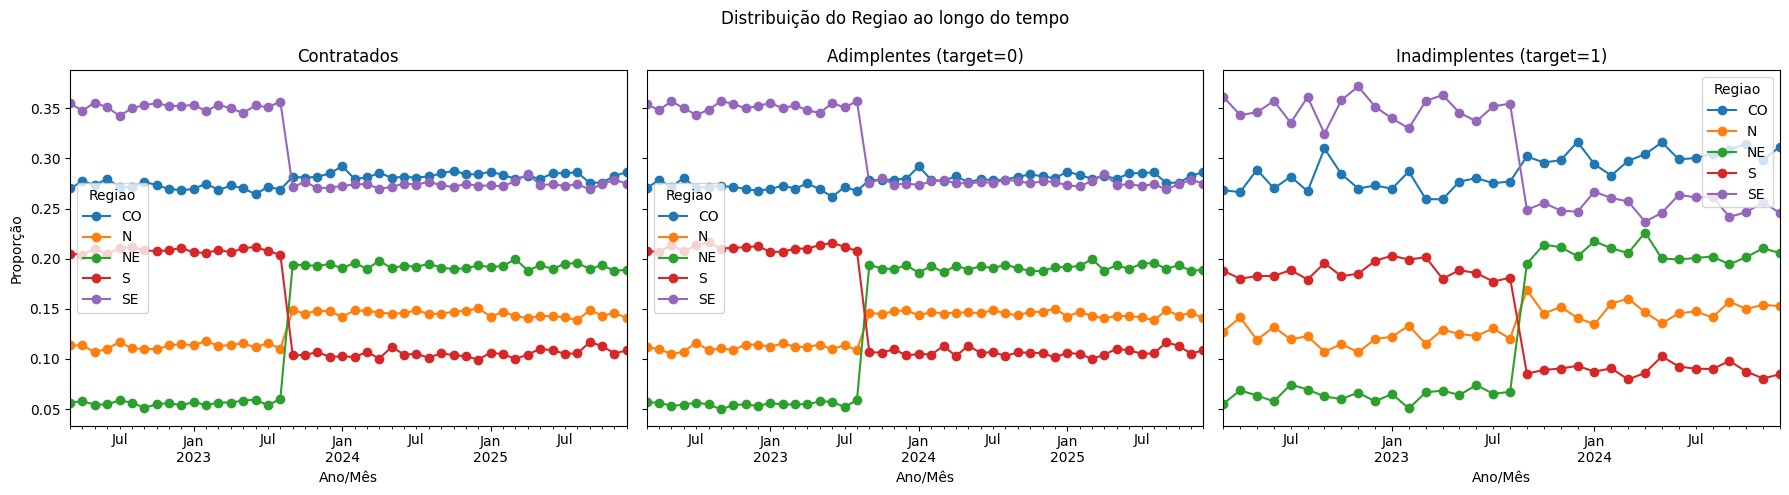

In [ ]:
# separar grupos
df_contratado = base[base['contratado'] == 1]
df_adimplente = base[base['target'] == 0]
df_inadimplente = base[base['target'] == 1]

# criar tabelas de distribuição
tab_contratado = pd.crosstab(
    df_contratado['ano_mes'],
    df_contratado['Regiao'],
    normalize='index'
)

tab_adimplente = pd.crosstab(
    df_adimplente['ano_mes'],
    df_adimplente['Regiao'],
    normalize='index'
)

tab_inadimplente = pd.crosstab(
    df_inadimplente['ano_mes'],
    df_inadimplente['Regiao'],
    normalize='index'
)

# criar gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Distribuição do Regiao ao longo do tempo')
plt.tight_layout()

plt.show()

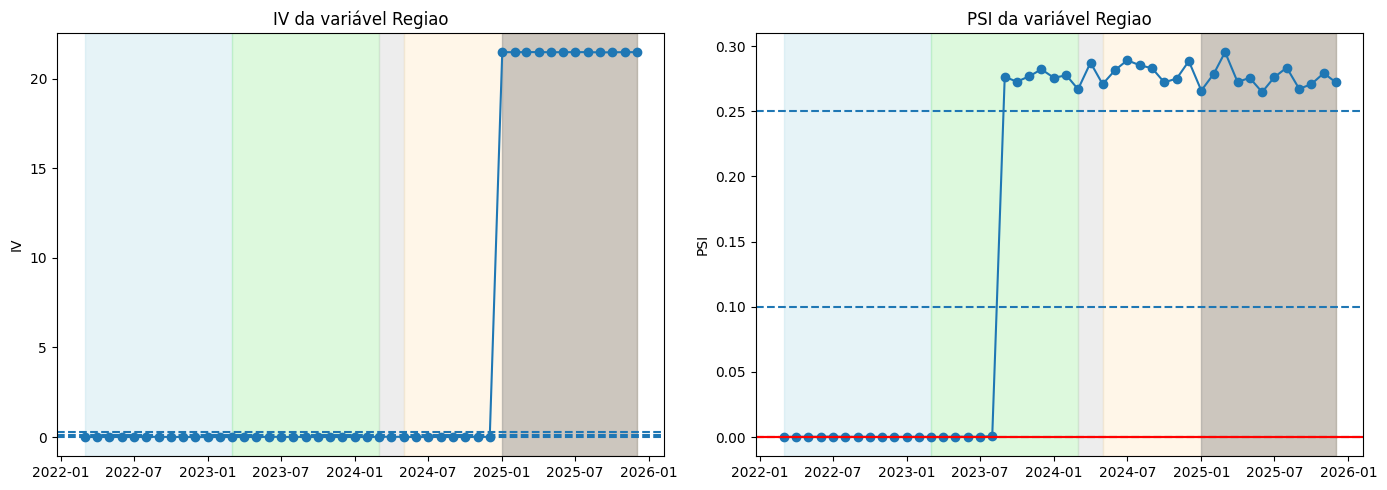

In [ ]:
variavel = 'Regiao'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

# tentar converter para numérico
try:
    df[variavel] = pd.to_numeric(df[variavel])
except:
    pass

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
]

# bins para PSI
if np.issubdtype(df[variavel].dtype, np.number):
    bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories
else:
    bins = base_modelagem[variavel].astype(str).unique()

iv_lista = []
psi_lista = []
meses = []

for mes, dados in df.groupby('ano_mes'):

    meses.append(mes)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados[variavel], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))

    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    if np.issubdtype(df[variavel].dtype, np.number):

        base_counts = pd.cut(base_modelagem[variavel], bins).value_counts(normalize=True)
        atual_counts = pd.cut(dados[variavel], bins).value_counts(normalize=True)

    else:

        base_counts = base_modelagem[variavel].value_counts(normalize=True)
        atual_counts = dados[variavel].value_counts(normalize=True)

    base_counts, atual_counts = base_counts.align(atual_counts, fill_value=0.0001)

    psi = ((base_counts-atual_counts)*np.log((base_counts+1e-10)/(atual_counts+1e-10))).sum()

    psi_lista.append(psi)

# dataframe final
result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS LADO A LADO
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title("IV da variável Regiao")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title("PSI da variável Regiao")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.tight_layout()
plt.show()

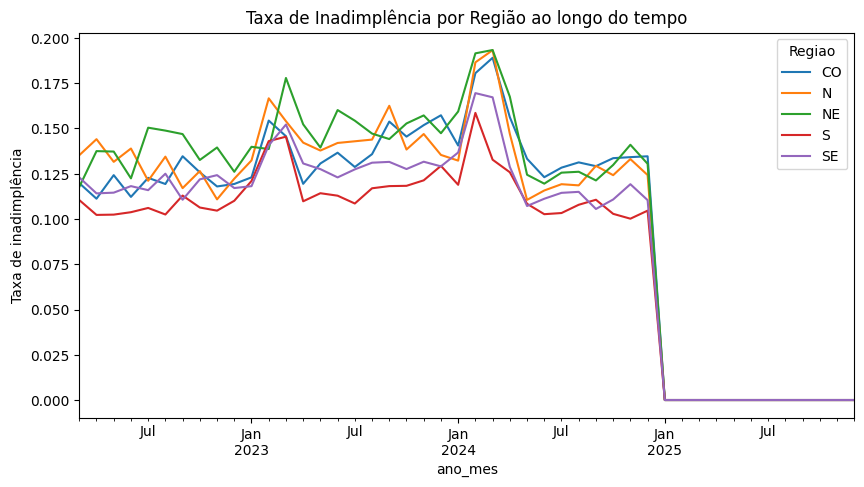

In [ ]:
inad_regiao = base.pivot_table(
    values='target',
    index='ano_mes',
    columns='Regiao',
    aggfunc='mean'
)

ax = inad_regiao.plot(figsize=(10,5))

plt.title('Taxa de Inadimplência por Região ao longo do tempo')
plt.ylabel('Taxa de inadimplência')
plt.show()

# **VARIÁVEL PROFISSÃO**
tipo: categórica

descrição: profissão do proponente

*É estável e baixo poder de predição.*

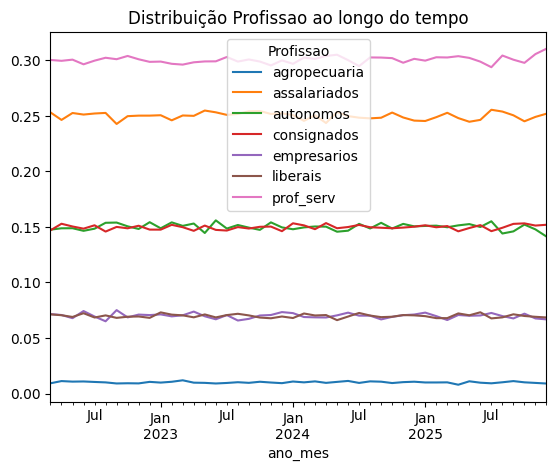

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['Profissao'], normalize='index')

tabela.plot()
plt.title('Distribuição Profissao ao longo do tempo')
plt.show()

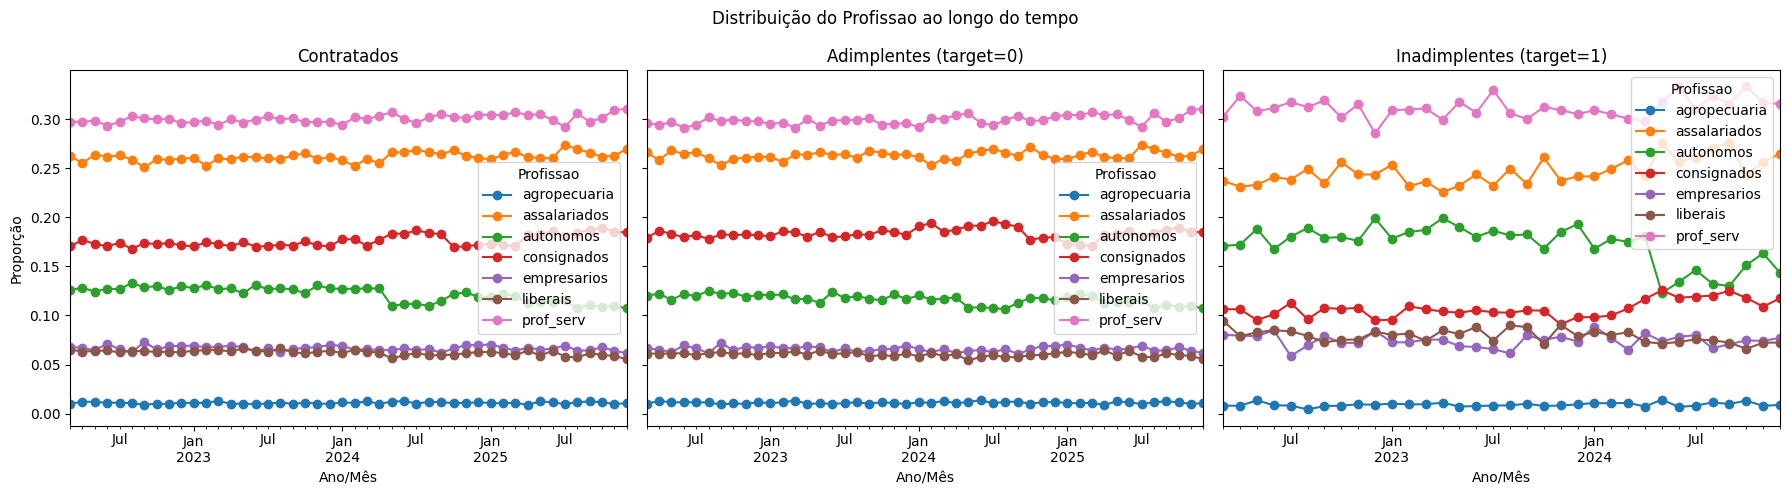

In [ ]:
# separar grupos
df_contratado = base[base['contratado'] == 1]
df_adimplente = base[base['target'] == 0]
df_inadimplente = base[base['target'] == 1]

# criar tabelas de distribuição
tab_contratado = pd.crosstab(
    df_contratado['ano_mes'],
    df_contratado['Profissao'],
    normalize='index'
)

tab_adimplente = pd.crosstab(
    df_adimplente['ano_mes'],
    df_adimplente['Profissao'],
    normalize='index'
)

tab_inadimplente = pd.crosstab(
    df_inadimplente['ano_mes'],
    df_inadimplente['Profissao'],
    normalize='index'
)

# criar gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Distribuição do Profissao ao longo do tempo')
plt.tight_layout()

plt.show()

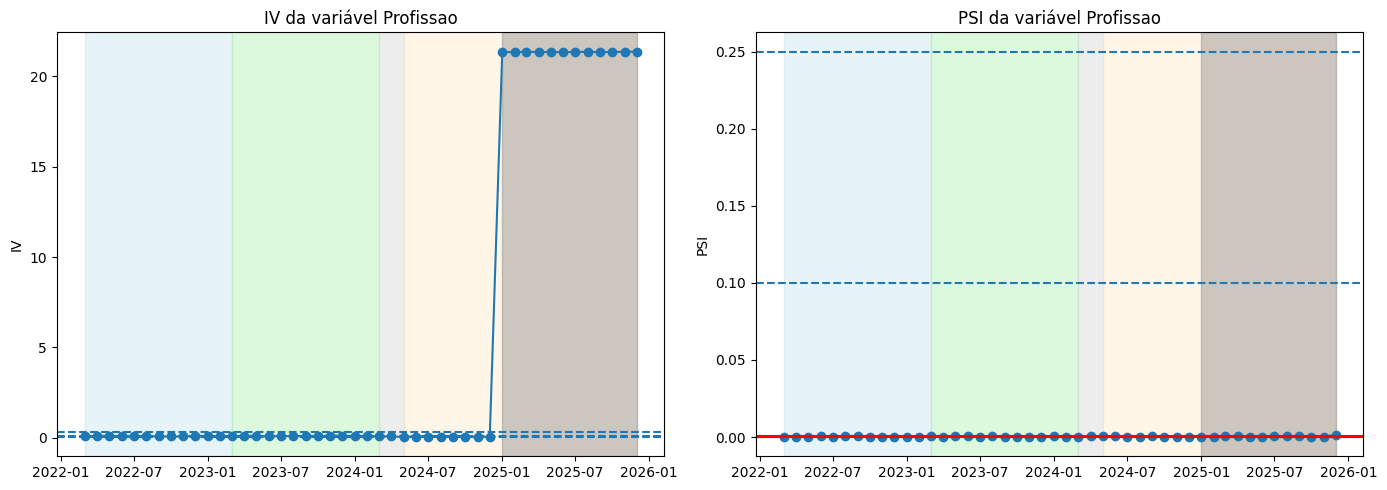

In [ ]:
variavel = 'Profissao'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

# tentar converter para numérico
try:
    df[variavel] = pd.to_numeric(df[variavel])
except:
    pass

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
]

# bins para PSI
if np.issubdtype(df[variavel].dtype, np.number):
    bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories
else:
    bins = base_modelagem[variavel].astype(str).unique()

iv_lista = []
psi_lista = []
meses = []

for mes, dados in df.groupby('ano_mes'):

    meses.append(mes)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados[variavel], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))

    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    if np.issubdtype(df[variavel].dtype, np.number):

        base_counts = pd.cut(base_modelagem[variavel], bins).value_counts(normalize=True)
        atual_counts = pd.cut(dados[variavel], bins).value_counts(normalize=True)

    else:

        base_counts = base_modelagem[variavel].value_counts(normalize=True)
        atual_counts = dados[variavel].value_counts(normalize=True)

    base_counts, atual_counts = base_counts.align(atual_counts, fill_value=0.0001)

    psi = ((base_counts-atual_counts)*np.log((base_counts+1e-10)/(atual_counts+1e-10))).sum()

    psi_lista.append(psi)

# dataframe final
result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS LADO A LADO
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title("IV da variável Profissao")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title("PSI da variável Profissao")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.tight_layout()
plt.show()

# **VARIÁVEL ENTRADA**
tipo: contínua

descrição: % proposto pelo proponente a dar de entrada na aquisição do veículo

*É estável e baixo poder de predição.*

In [ ]:
base['entrada'].unique()

array([20, 30, 40, 50, 10,  0])

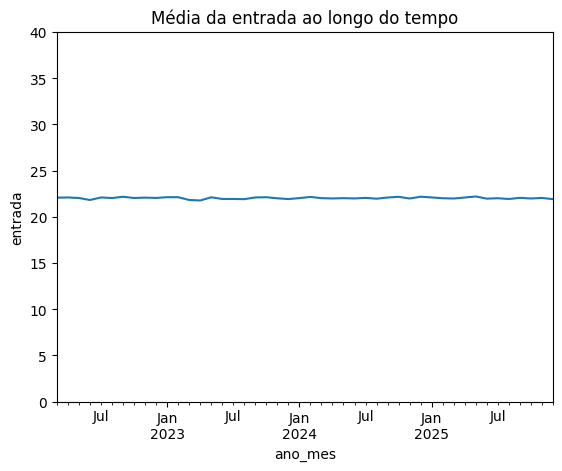

In [ ]:
entrada_tempo = base.groupby('ano_mes')['entrada'].mean()

entrada_tempo.plot()
plt.title('Média da entrada ao longo do tempo')
plt.xlabel('ano_mes')
plt.ylabel('entrada')
plt.ylim(0,40)
plt.show()

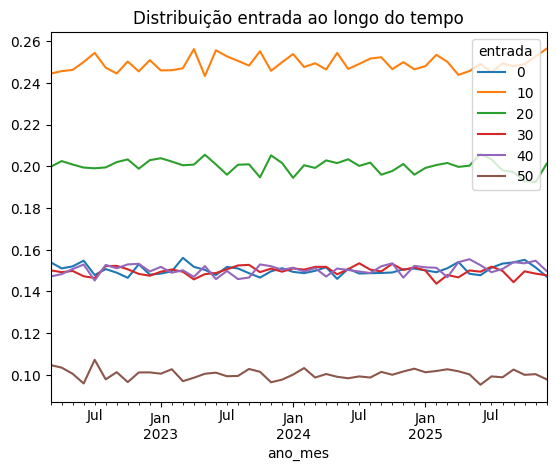

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['entrada'], normalize='index')

tabela.plot()
plt.title('Distribuição entrada ao longo do tempo')
plt.show()

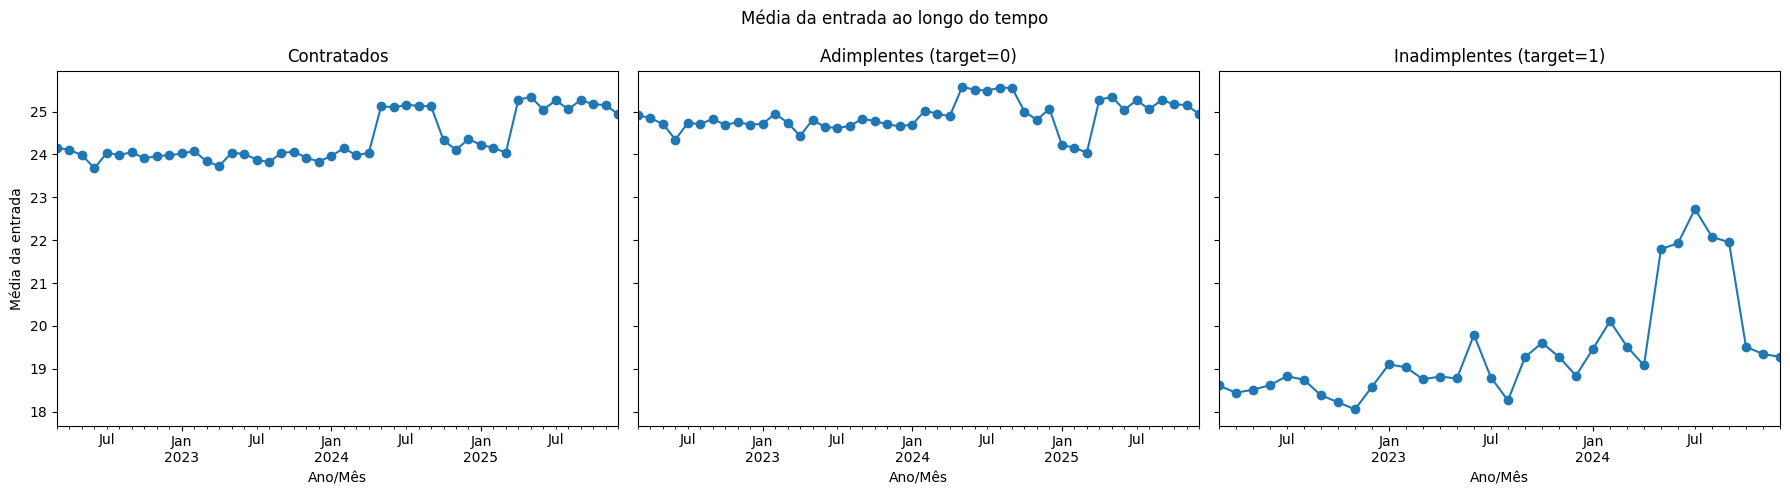

In [ ]:
# média do valor do bem por mês
tab_contratado = df_contratado.groupby('ano_mes')['entrada'].mean()
tab_adimplente = df_adimplente.groupby('ano_mes')['entrada'].mean()
tab_inadimplente = df_inadimplente.groupby('ano_mes')['entrada'].mean()

# gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Média da entrada')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Média da entrada ao longo do tempo')

plt.tight_layout()
plt.show()

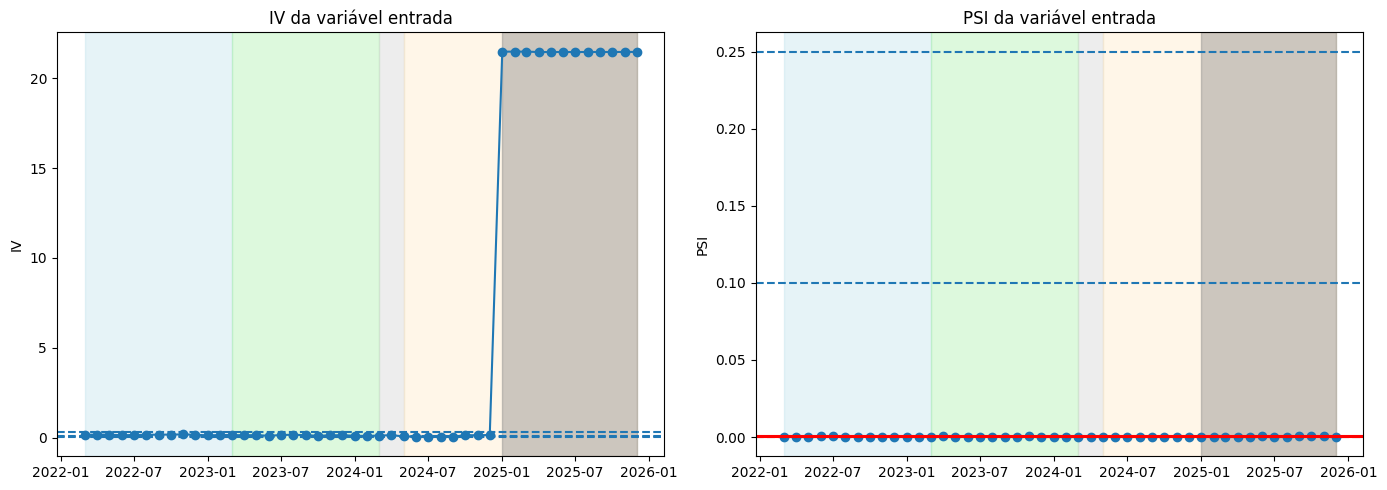

In [ ]:
variavel = 'entrada'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])
df[variavel] = pd.to_numeric(df[variavel], errors='coerce')

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
].copy()

# criar bins usando apenas a base de modelagem
bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories

iv_lista = []
psi_lista = []
meses = []

# distribuição da base (para PSI)
base_modelagem['bin'] = pd.cut(base_modelagem[variavel], bins)
base_dist = base_modelagem['bin'].value_counts(normalize=True)

# ---------------------------
# LOOP POR MÊS
# ---------------------------

for mes, dados in df.groupby('ano_mes'):

    dados = dados.copy()
    meses.append(mes)

    dados['bin'] = pd.cut(dados[variavel], bins)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados['bin'], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))
    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    atual_dist = dados['bin'].value_counts(normalize=True)

    base_aligned, atual_aligned = base_dist.align(atual_dist, fill_value=0.0001)

    psi = ((base_aligned-atual_aligned) *
           np.log((base_aligned+1e-10)/(atual_aligned+1e-10))).sum()

    psi_lista.append(psi)

# ---------------------------
# RESULTADO FINAL
# ---------------------------

result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title(f"IV da variável {variavel}")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title(f"PSI da variável {variavel}")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01','2025-12-01',color='gray',alpha=0.4)

plt.tight_layout()
plt.show()

# **VARIÁVEL PRAZO**
tipo: contínua

descrição: 	quantidade de parcelas que o proponente pretende pagar

*Muda a estabilidade e baixo poder de predição.*

In [ ]:
base['prazo'].unique()

array([12, 48, 36, 24, 60])

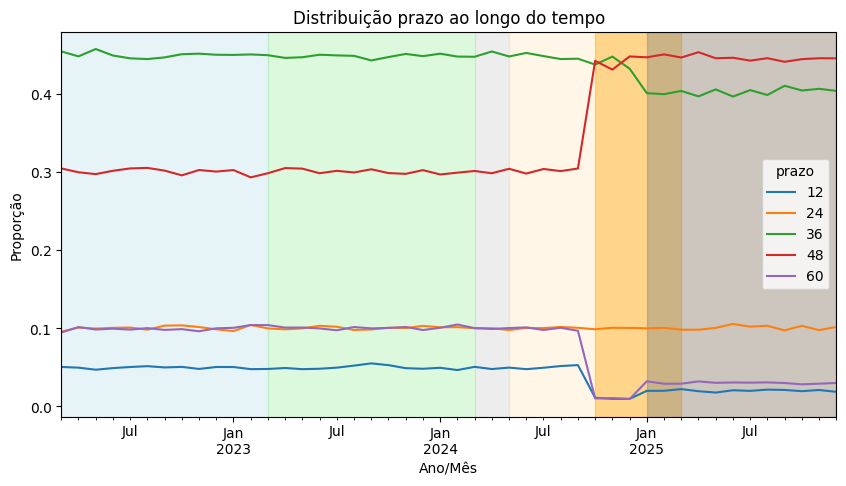

In [ ]:
base['ano_mes'] = pd.to_datetime(base['ano_mes'])

tabela = pd.crosstab(base['ano_mes'], base['prazo'], normalize='index')

prazo = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
prazo.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
prazo.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
prazo.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
prazo.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)  # implantado
prazo.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
prazo.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('Distribuição prazo ao longo do tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('Proporção')

plt.show()

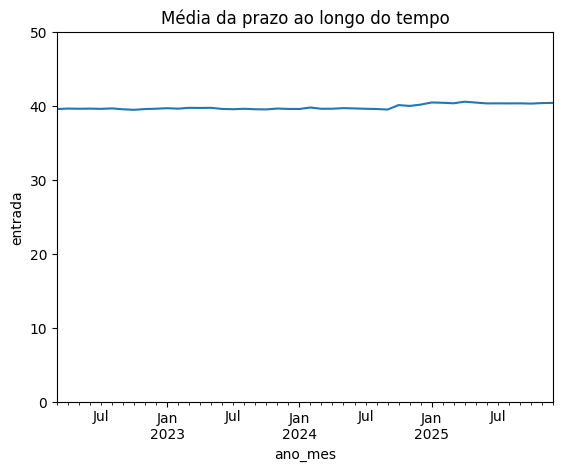

In [ ]:
entrada_tempo = base.groupby('ano_mes')['prazo'].mean()

entrada_tempo.plot()
plt.title('Média da prazo ao longo do tempo')
plt.xlabel('ano_mes')
plt.ylabel('entrada')
plt.ylim(0,50)
plt.show()

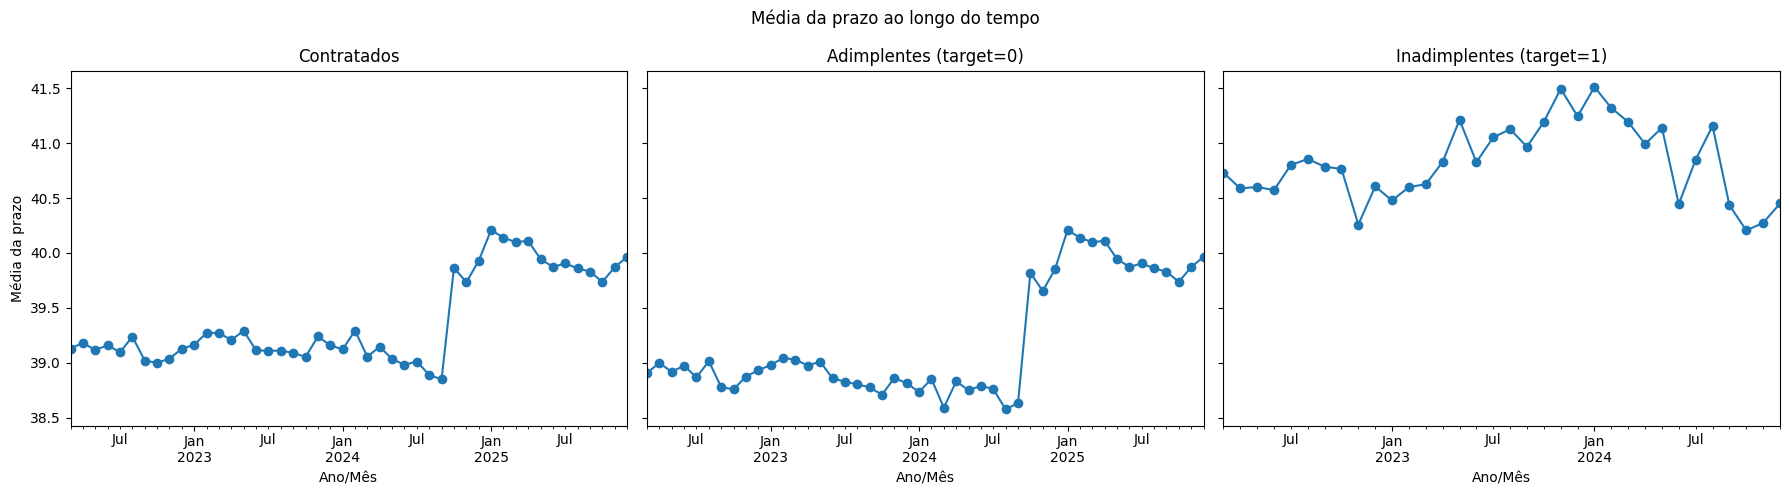

In [ ]:
# média do valor do bem por mês
tab_contratado = df_contratado.groupby('ano_mes')['prazo'].mean()
tab_adimplente = df_adimplente.groupby('ano_mes')['prazo'].mean()
tab_inadimplente = df_inadimplente.groupby('ano_mes')['prazo'].mean()

# gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Média da prazo')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Média da prazo ao longo do tempo')

plt.tight_layout()
plt.show()

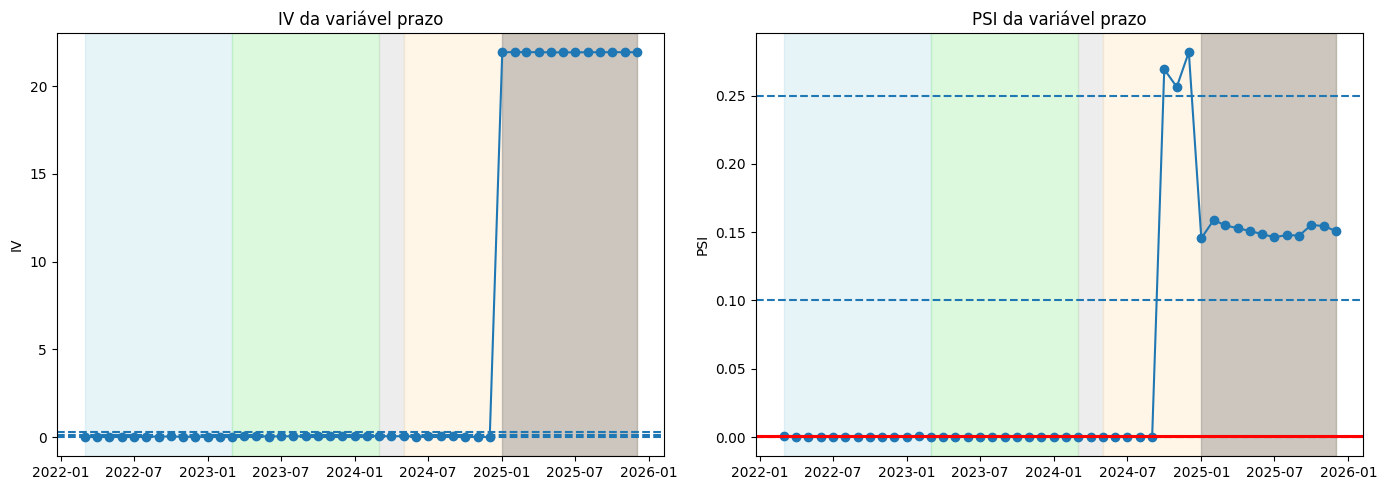

In [ ]:
variavel = 'prazo'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])
df[variavel] = pd.to_numeric(df[variavel], errors='coerce')

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
].copy()

# criar bins usando apenas a base de modelagem
bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories

iv_lista = []
psi_lista = []
meses = []

# distribuição da base (para PSI)
base_modelagem['bin'] = pd.cut(base_modelagem[variavel], bins)
base_dist = base_modelagem['bin'].value_counts(normalize=True)

# ---------------------------
# LOOP POR MÊS
# ---------------------------

for mes, dados in df.groupby('ano_mes'):

    dados = dados.copy()
    meses.append(mes)

    dados['bin'] = pd.cut(dados[variavel], bins)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados['bin'], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))
    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    atual_dist = dados['bin'].value_counts(normalize=True)

    base_aligned, atual_aligned = base_dist.align(atual_dist, fill_value=0.0001)

    psi = ((base_aligned-atual_aligned) *
           np.log((base_aligned+1e-10)/(atual_aligned+1e-10))).sum()

    psi_lista.append(psi)

# ---------------------------
# RESULTADO FINAL
# ---------------------------

result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title(f"IV da variável {variavel}")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title(f"PSI da variável {variavel}")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01','2025-12-01',color='gray',alpha=0.4)

plt.tight_layout()
plt.show()

# **VARIÁVEL PMT**
tipo: contínua

descrição: valor da prestação

*Muda a estabilidade e baixo poder de predição.*

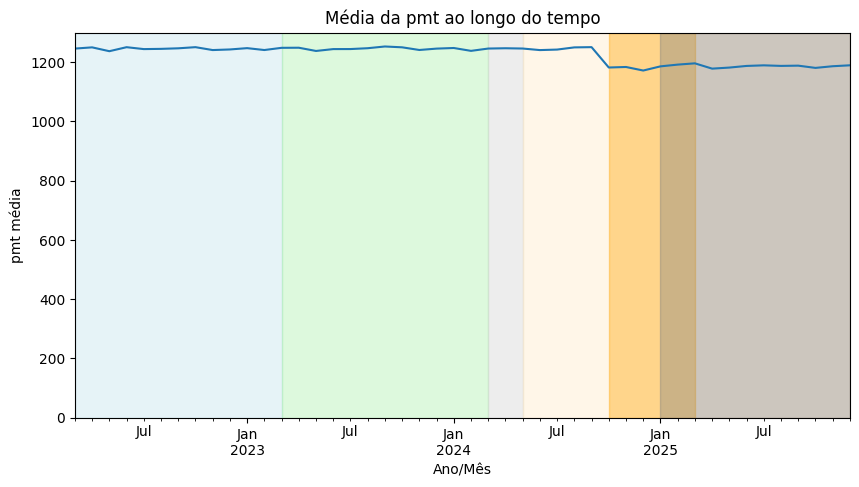

In [ ]:
base['ano_mes'] = pd.to_datetime(base['ano_mes'])

pmt_tempo = base.groupby('ano_mes')['pmt'].mean()

ax = pmt_tempo.plot(figsize=(10,5))

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
ax.axvspan('2024-05-01', pmt_tempo.index.max(), color='moccasin', alpha=0.3)  # implantado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.title('Média da pmt ao longo do tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('pmt média')
plt.ylim(0,1300)

plt.show()

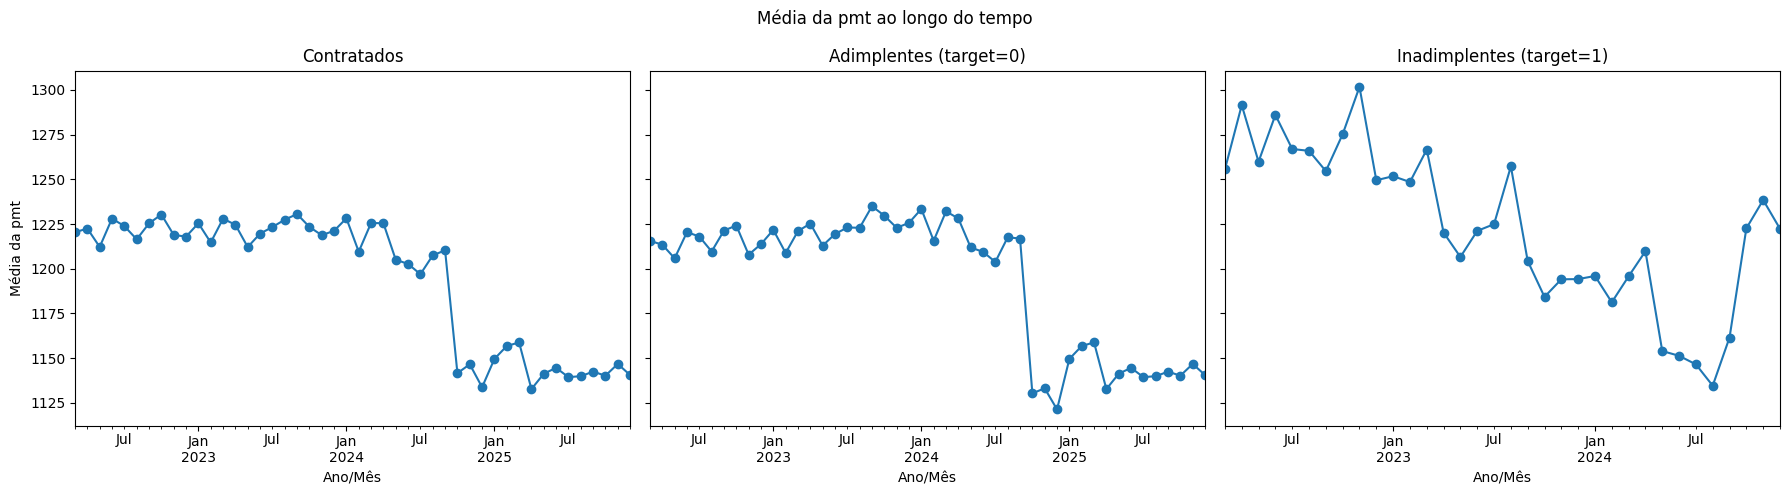

In [ ]:
# média do pmt por mês
tab_contratado = df_contratado.groupby('ano_mes')['pmt'].mean()
tab_adimplente = df_adimplente.groupby('ano_mes')['pmt'].mean()
tab_inadimplente = df_inadimplente.groupby('ano_mes')['pmt'].mean()

# gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Média da pmt')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Média da pmt ao longo do tempo')

plt.tight_layout()
plt.show()

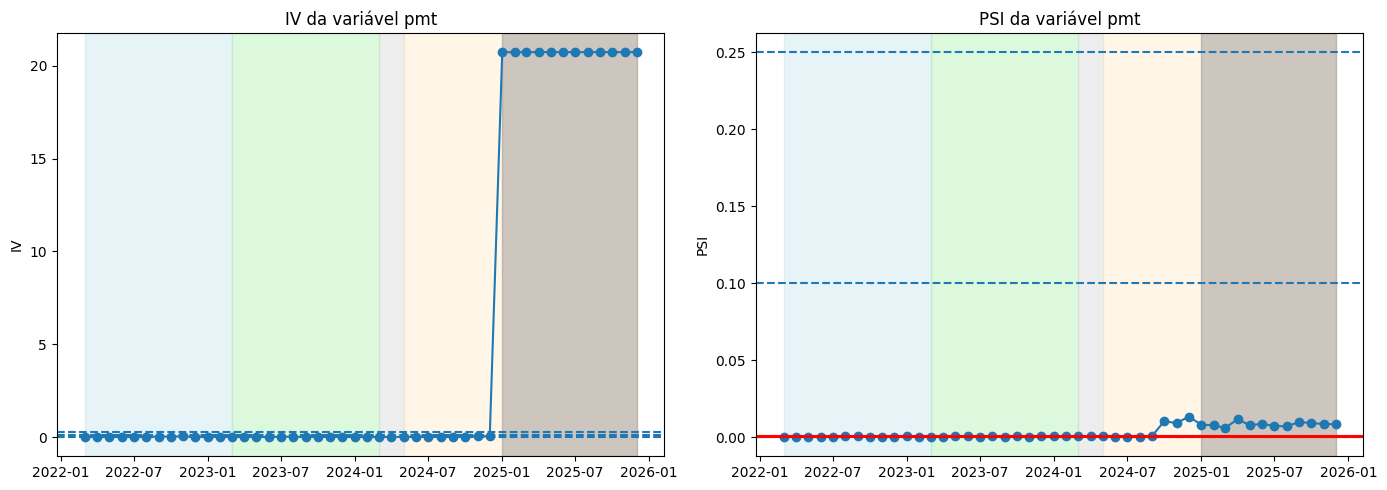

In [ ]:
variavel = 'pmt'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])
df[variavel] = pd.to_numeric(df[variavel], errors='coerce')

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
].copy()

# criar bins usando apenas a base de modelagem
bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories

iv_lista = []
psi_lista = []
meses = []

# distribuição da base (para PSI)
base_modelagem['bin'] = pd.cut(base_modelagem[variavel], bins)
base_dist = base_modelagem['bin'].value_counts(normalize=True)

# ---------------------------
# LOOP POR MÊS
# ---------------------------

for mes, dados in df.groupby('ano_mes'):

    dados = dados.copy()
    meses.append(mes)

    dados['bin'] = pd.cut(dados[variavel], bins)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados['bin'], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))
    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    atual_dist = dados['bin'].value_counts(normalize=True)

    base_aligned, atual_aligned = base_dist.align(atual_dist, fill_value=0.0001)

    psi = ((base_aligned-atual_aligned) *
           np.log((base_aligned+1e-10)/(atual_aligned+1e-10))).sum()

    psi_lista.append(psi)

# ---------------------------
# RESULTADO FINAL
# ---------------------------

result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title(f"IV da variável {variavel}")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title(f"PSI da variável {variavel}")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01','2025-12-01',color='gray',alpha=0.4)

plt.tight_layout()
plt.show()

# **VARIÁVEL FDP**
tipo: dicotômica

descrição: 	se o contrato teve inadimplencia na 1a parcela (1) ou não (0). Se estiver vazio é porque o contrato não foi efetivado

*É estável e baixo poder de predição.*

In [ ]:
base['FPD'].unique()

array([ 0., nan,  1.])

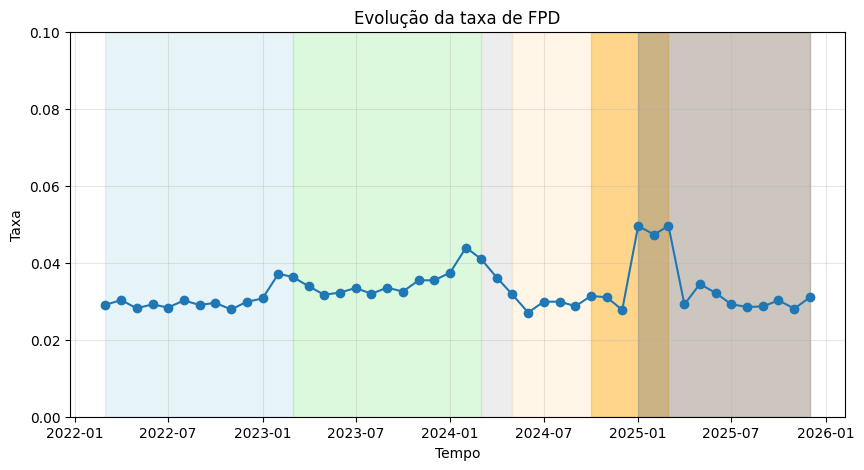

In [ ]:
fpd_tempo = base.groupby('ano_mes')['FPD'].mean()

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(fpd_tempo.index, fpd_tempo.values, marker='o')

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
ax.axvspan('2024-05-01', fpd_tempo.index.max(), color='moccasin', alpha=0.3)  # implantado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

ax.grid(alpha=0.3)

ax.set_title('Evolução da taxa de FPD')
ax.set_ylabel('Taxa')
ax.set_xlabel('Tempo')
ax.set_ylim(0,0.1)

plt.show()

PILAR 1 - ESTABILIDADE

In [ ]:
# usar base com FPD
df = base[base["FPD"].notna()].copy()

# criar decis de FPD
df["decil"] = pd.qcut(df["FPD"], 10, labels=False, duplicates="drop") + 1

# período base
base_periodo = df[df["ano_mes"] < "2024-01-01"]

# distribuição base
dist_base = base_periodo["decil"].value_counts(normalize=True).sort_index()

psi_lista = []

# calcular PSI por mês
for mes, dados in df.groupby("ano_mes"):

    dist_mes = dados["decil"].value_counts(normalize=True).sort_index()

    tabela = pd.concat([dist_base, dist_mes], axis=1)
    tabela.columns = ["base", "atual"]

    tabela = tabela.fillna(0.0001)

    tabela["psi"] = (tabela["atual"] - tabela["base"]) * np.log(tabela["atual"] / tabela["base"])

    psi = tabela["psi"].sum()

    psi_lista.append({"ano_mes": mes, "PSI": psi})

psi_tempo = pd.DataFrame(psi_lista)

print(psi_tempo)

      ano_mes  PSI
0  2022-03-01  0.0
1  2022-04-01  0.0
2  2022-05-01  0.0
3  2022-06-01  0.0
4  2022-07-01  0.0
5  2022-08-01  0.0
6  2022-09-01  0.0
7  2022-10-01  0.0
8  2022-11-01  0.0
9  2022-12-01  0.0
10 2023-01-01  0.0
11 2023-02-01  0.0
12 2023-03-01  0.0
13 2023-04-01  0.0
14 2023-05-01  0.0
15 2023-06-01  0.0
16 2023-07-01  0.0
17 2023-08-01  0.0
18 2023-09-01  0.0
19 2023-10-01  0.0
20 2023-11-01  0.0
21 2023-12-01  0.0
22 2024-01-01  0.0
23 2024-02-01  0.0
24 2024-03-01  0.0
25 2024-04-01  0.0
26 2024-05-01  0.0
27 2024-06-01  0.0
28 2024-07-01  0.0
29 2024-08-01  0.0
30 2024-09-01  0.0
31 2024-10-01  0.0
32 2024-11-01  0.0
33 2024-12-01  0.0
34 2025-01-01  0.0
35 2025-02-01  0.0
36 2025-03-01  0.0
37 2025-04-01  0.0
38 2025-05-01  0.0
39 2025-06-01  0.0
40 2025-07-01  0.0
41 2025-08-01  0.0
42 2025-09-01  0.0
43 2025-10-01  0.0
44 2025-11-01  0.0
45 2025-12-01  0.0


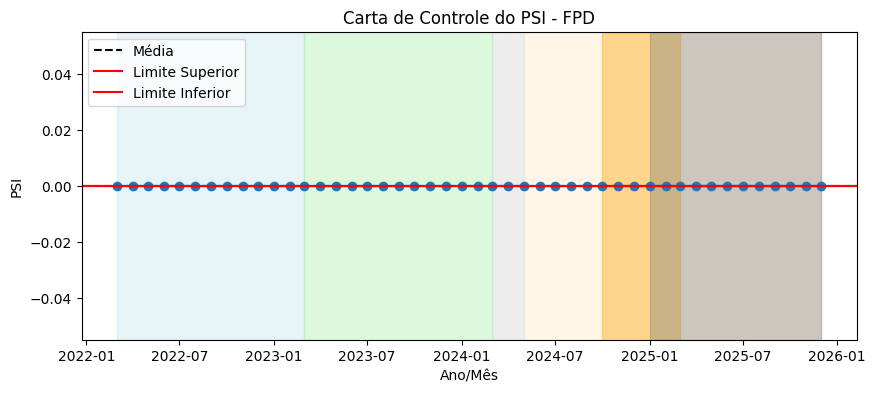

In [ ]:
## PSI com carta de controle para a variável FDP
obs = psi_tempo[
    (psi_tempo["ano_mes"] >= "2022-03-01") &
    (psi_tempo["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = media - 2*std

fig, ax = plt.subplots(figsize=(10,4))

# pintar fundo dos períodos
ax.axvspan(pd.to_datetime('2022-03-01'), pd.to_datetime('2023-03-01'), color='lightblue', alpha=0.3)   # modelagem
ax.axvspan(pd.to_datetime('2023-03-01'), pd.to_datetime('2024-03-01'), color='lightgreen', alpha=0.3)  # observação
ax.axvspan(pd.to_datetime('2024-03-01'), pd.to_datetime('2024-05-01'), color='lightgray', alpha=0.4)   # limbo
ax.axvspan(pd.to_datetime('2024-05-01'), psi_tempo["ano_mes"].max(), color='moccasin', alpha=0.3)      # implantado
ax.axvspan(pd.to_datetime('2024-10-01'), pd.to_datetime('2025-03-01'), color='orange', alpha=0.4)      # deu ruim
ax.axvspan(pd.to_datetime('2025-01-01'), pd.to_datetime('2025-12-01'), color='gray', alpha=0.4)        # sem target

# linha PSI
ax.plot(psi_tempo["ano_mes"], psi_tempo["PSI"], marker="o")

# linhas de controle
ax.axhline(media, linestyle="--", color="black", label="Média")
ax.axhline(ucl, linestyle="-", color="red", label="Limite Superior")
ax.axhline(lcl, linestyle="-", color="red", label="Limite Inferior")

ax.set_title("Carta de Controle do PSI - FPD")
ax.set_xlabel("Ano/Mês")
ax.set_ylabel("PSI")

ax.legend()

plt.show()

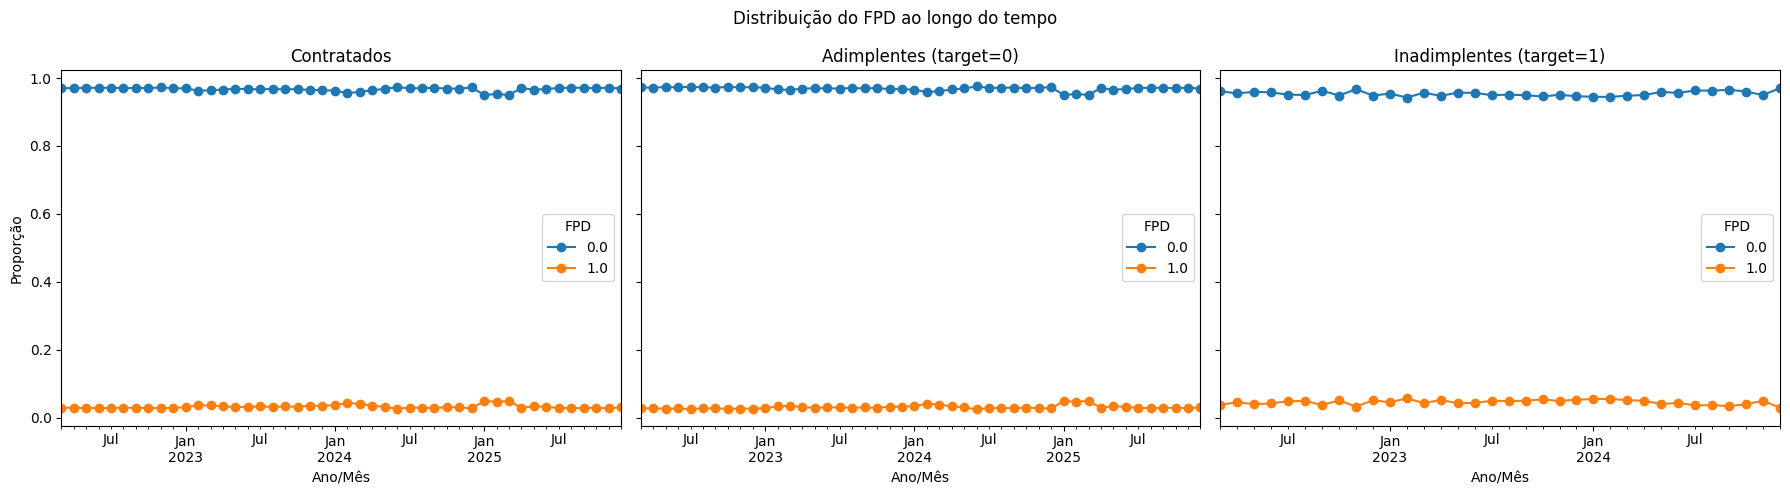

In [ ]:
# separar grupos
df_contratado = base[base['contratado'] == 1]
df_adimplente = base[base['target'] == 0]
df_inadimplente = base[base['target'] == 1]

# criar tabelas de distribuição
tab_contratado = pd.crosstab(
    df_contratado['ano_mes'],
    df_contratado['FPD'],
    normalize='index'
)

tab_adimplente = pd.crosstab(
    df_adimplente['ano_mes'],
    df_adimplente['FPD'],
    normalize='index'
)

tab_inadimplente = pd.crosstab(
    df_inadimplente['ano_mes'],
    df_inadimplente['FPD'],
    normalize='index'
)

# criar gráficos lado a lado
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

tab_contratado.plot(ax=axes[0], marker='o')
axes[0].set_title('Contratados')
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('Ano/Mês')

tab_adimplente.plot(ax=axes[1], marker='o')
axes[1].set_title('Adimplentes (target=0)')
axes[1].set_xlabel('Ano/Mês')

tab_inadimplente.plot(ax=axes[2], marker='o')
axes[2].set_title('Inadimplentes (target=1)')
axes[2].set_xlabel('Ano/Mês')

plt.suptitle('Distribuição do FPD ao longo do tempo')
plt.tight_layout()

plt.show()

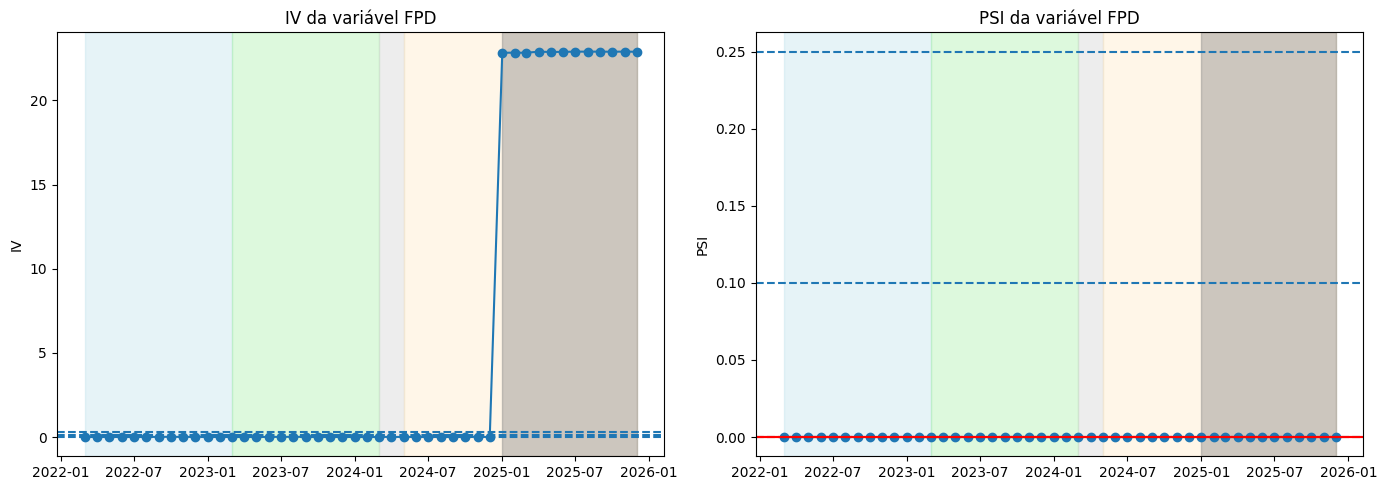

In [ ]:
variavel = 'FPD'

df = base.copy()
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

# tentar converter para numérico
try:
    df[variavel] = pd.to_numeric(df[variavel])
except:
    pass

# ---------------------------
# BASE DE MODELAGEM
# ---------------------------

base_modelagem = df[
    (df['ano_mes'] >= '2022-03-01') &
    (df['ano_mes'] < '2023-03-01')
]

# bins para PSI
if np.issubdtype(df[variavel].dtype, np.number):
    bins = pd.qcut(base_modelagem[variavel], q=10, duplicates='drop').cat.categories
else:
    bins = base_modelagem[variavel].astype(str).unique()

iv_lista = []
psi_lista = []
meses = []

for mes, dados in df.groupby('ano_mes'):

    meses.append(mes)

    # ---------------------------
    # IV
    # ---------------------------

    tab = pd.crosstab(dados[variavel], dados['target'])

    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab.rename(columns={0:'bons',1:'maus'})

    dist_bons = tab['bons']/(tab['bons'].sum()+1e-10)
    dist_maus = tab['maus']/(tab['maus'].sum()+1e-10)

    woe = np.log((dist_bons+1e-10)/(dist_maus+1e-10))

    iv = ((dist_bons-dist_maus)*woe).sum()

    iv_lista.append(iv)

    # ---------------------------
    # PSI
    # ---------------------------

    if np.issubdtype(df[variavel].dtype, np.number):

        base_counts = pd.cut(base_modelagem[variavel], bins).value_counts(normalize=True)
        atual_counts = pd.cut(dados[variavel], bins).value_counts(normalize=True)

    else:

        base_counts = base_modelagem[variavel].value_counts(normalize=True)
        atual_counts = dados[variavel].value_counts(normalize=True)

    base_counts, atual_counts = base_counts.align(atual_counts, fill_value=0.0001)

    psi = ((base_counts-atual_counts)*np.log((base_counts+1e-10)/(atual_counts+1e-10))).sum()

    psi_lista.append(psi)

# dataframe final
result = pd.DataFrame({
    'ano_mes': meses,
    'IV': iv_lista,
    'PSI': psi_lista
}).sort_values('ano_mes')

# ---------------------------
# CARTA DE CONTROLE PSI
# ---------------------------

obs = result[
    (result["ano_mes"] >= "2022-03-01") &
    (result["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = max(0, media - 2*std)

# ---------------------------
# GRÁFICOS LADO A LADO
# ---------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# IV
axes[0].plot(result["ano_mes"], result["IV"], marker="o")
axes[0].axhline(0.02, linestyle='--')
axes[0].axhline(0.1, linestyle='--')
axes[0].axhline(0.3, linestyle='--')

axes[0].set_title("IV da variável FPD")
axes[0].set_ylabel("IV")

# PSI
axes[1].plot(result["ano_mes"], result["PSI"], marker="o")

axes[1].axhline(media, linestyle="--", color="black", label="Média")
axes[1].axhline(ucl, color="red", label="Limite superior")
axes[1].axhline(lcl, color="red", label="Limite inferior")

axes[1].axhline(0.1, linestyle="--")
axes[1].axhline(0.25, linestyle="--")

axes[1].set_title("PSI da variável FPD")
axes[1].set_ylabel("PSI")

# pintar períodos
for ax in axes:

    ax.axvspan('2022-03-01','2023-03-01',color='lightblue',alpha=0.3)
    ax.axvspan('2023-03-01','2024-03-01',color='lightgreen',alpha=0.3)
    ax.axvspan('2024-03-01','2024-05-01',color='lightgray',alpha=0.4)
    ax.axvspan('2024-05-01',result['ano_mes'].max(),color='moccasin',alpha=0.3)
    ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

plt.tight_layout()
plt.show()

# **VARIÁVEL SCORE**

tipo: categórico

descrição: Qualidade de crédito baseado no modelo estatístico desenvolvido pelo banco (usando o período de 2017)

In [ ]:
base['score'].unique()

array([ 8,  5,  7,  4,  6,  3,  9,  1,  2, 10])

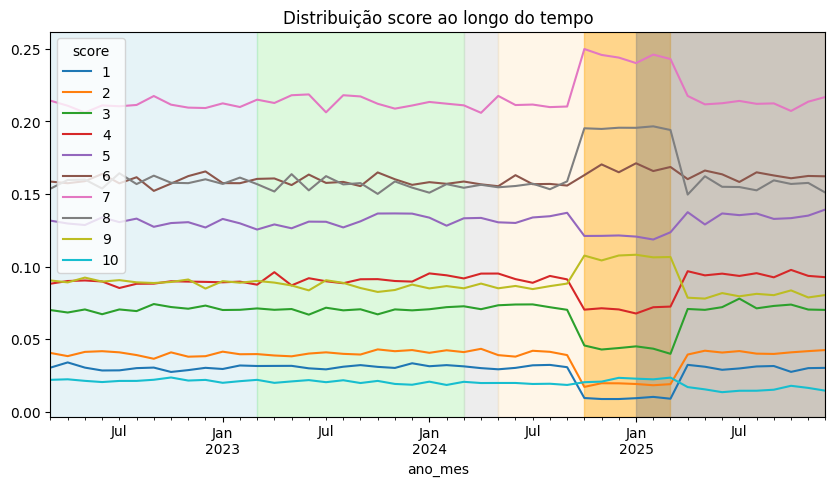

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['score'], normalize='index')

score = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
score.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3) # modelagem
score.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3) # janela de observação
score.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4) # limbo
score.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3) # foi implatado
score.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4) # deu ruim
score.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4) # sem target

plt.title('Distribuição score ao longo do tempo')
plt.show()

### **PILAR 1: ESTABILIDADE**

In [ ]:
## PSI para a variável SCORE

# usar toda a base que possui score
df = base[base["score"].notna()].copy()

# criar decis de score
df["decil"] = pd.qcut(df["score"], 10, labels=False, duplicates="drop") + 1

# escolher período base (ex: 2023)
base_periodo = df[df["ano_mes"] < "2024-01-01"]

dist_base = base_periodo["decil"].value_counts(normalize=True).sort_index()

psi_lista = []

for mes, dados in df.groupby("ano_mes"):

    dist_mes = dados["decil"].value_counts(normalize=True).sort_index()

    tabela = pd.concat([dist_base, dist_mes], axis=1)
    tabela.columns = ["base", "atual"]

    tabela = tabela.fillna(0.0001)

    tabela["psi"] = (tabela["atual"] - tabela["base"]) * np.log(tabela["atual"] / tabela["base"])

    psi = tabela["psi"].sum()

    psi_lista.append({"ano_mes": mes, "PSI": psi})

psi_tempo = pd.DataFrame(psi_lista)

print(psi_tempo)

      ano_mes       PSI
0  2022-03-01  0.000240
1  2022-04-01  0.000148
2  2022-05-01  0.000463
3  2022-06-01  0.000439
4  2022-07-01  0.000597
5  2022-08-01  0.000156
6  2022-09-01  0.000748
7  2022-10-01  0.000330
8  2022-11-01  0.000267
9  2022-12-01  0.000619
10 2023-01-01  0.000155
11 2023-02-01  0.000148
12 2023-03-01  0.000397
13 2023-04-01  0.000801
14 2023-05-01  0.000675
15 2023-06-01  0.000910
16 2023-07-01  0.000421
17 2023-08-01  0.000302
18 2023-09-01  0.000441
19 2023-10-01  0.001252
20 2023-11-01  0.000768
21 2023-12-01  0.000873
22 2024-01-01  0.000887
23 2024-02-01  0.000913
24 2024-03-01  0.000448
25 2024-04-01  0.000807
26 2024-05-01  0.000827
27 2024-06-01  0.000282
28 2024-07-01  0.000838
29 2024-08-01  0.000835
30 2024-09-01  0.000785
31 2024-10-01  0.069220
32 2024-11-01  0.068360
33 2024-12-01  0.067881
34 2025-01-01  0.067319
35 2025-02-01  0.068486
36 2025-03-01  0.073140
37 2025-04-01  0.003504
38 2025-05-01  0.003771
39 2025-06-01  0.004678
40 2025-07-01  0

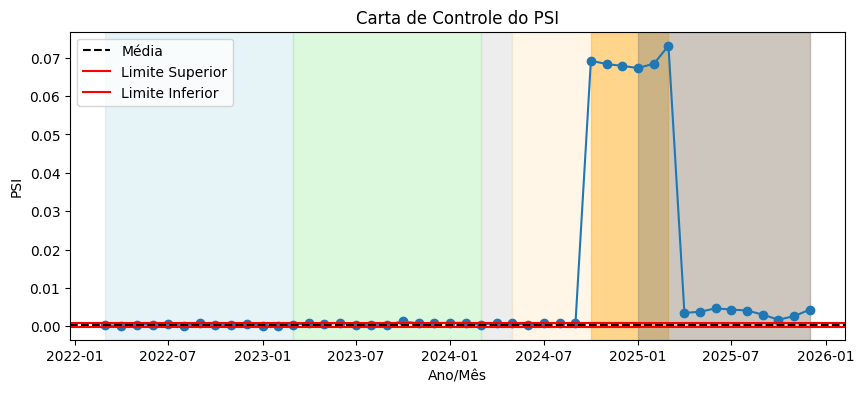

In [ ]:
## PSI com carta de controle para a variável SCORE
obs = psi_tempo[
    (psi_tempo["ano_mes"] >= "2022-03-01") &
    (psi_tempo["ano_mes"] < "2023-03-01")
]

media = obs["PSI"].mean()
std = obs["PSI"].std()

ucl = media + 2*std
lcl = media - 2*std

fig, ax = plt.subplots(figsize=(10,4))

# pintar fundo dos períodos
ax.axvspan(pd.to_datetime('2022-03-01'), pd.to_datetime('2023-03-01'), color='lightblue', alpha=0.3)   # modelagem
ax.axvspan(pd.to_datetime('2023-03-01'), pd.to_datetime('2024-03-01'), color='lightgreen', alpha=0.3)  # observação
ax.axvspan(pd.to_datetime('2024-03-01'), pd.to_datetime('2024-05-01'), color='lightgray', alpha=0.4)   # limbo
ax.axvspan(pd.to_datetime('2024-05-01'), psi_tempo["ano_mes"].max(), color='moccasin', alpha=0.3)      # implantado
ax.axvspan(pd.to_datetime('2024-10-01'), pd.to_datetime('2025-03-01'), color='orange', alpha=0.4)      # deu ruim
ax.axvspan(pd.to_datetime('2025-01-01'), pd.to_datetime('2025-12-01'), color='gray', alpha=0.4)        # sem target

# linha PSI
ax.plot(psi_tempo["ano_mes"], psi_tempo["PSI"], marker="o")

# linhas de controle
ax.axhline(media, linestyle="--", color="black", label="Média")
ax.axhline(ucl, linestyle="-", color="red", label="Limite Superior")
ax.axhline(lcl, linestyle="-", color="red", label="Limite Inferior")

ax.set_title("Carta de Controle do PSI")
ax.set_xlabel("Ano/Mês")
ax.set_ylabel("PSI")

ax.legend()

plt.show()

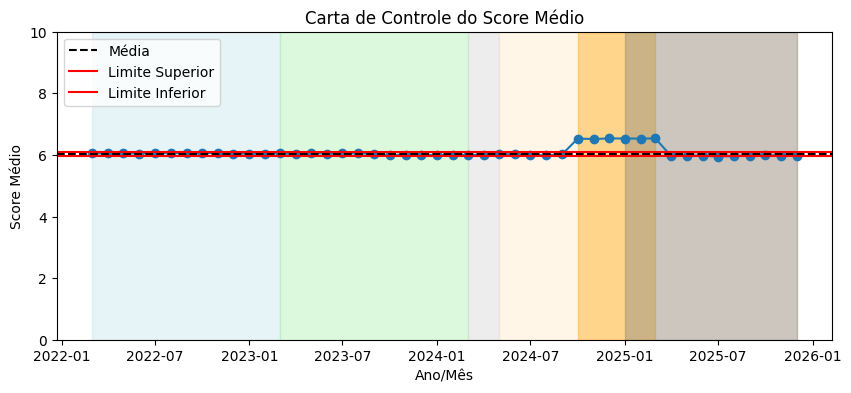

In [ ]:
## SCORE MÉDIO com carta de controle para a variável SCORE

score_medio = base.groupby("ano_mes")["score"].mean().reset_index(name="score_medio")

# período de observação (baseline)
obs = score_medio[
    (score_medio["ano_mes"] >= "2023-02-01") &
    (score_medio["ano_mes"] <= "2024-02-01")
]

# média e desvio apenas do período de observação
media = obs["score_medio"].mean()
std = obs["score_medio"].std()

ucl = media + 2*std
lcl = media - 2*std


fig, ax = plt.subplots(figsize=(10,4))

# pintar fundo dos períodos
ax.axvspan(pd.to_datetime('2022-03-01'), pd.to_datetime('2023-03-01'), color='lightblue', alpha=0.3)   # modelagem
ax.axvspan(pd.to_datetime('2023-03-01'), pd.to_datetime('2024-03-01'), color='lightgreen', alpha=0.3)  # observação
ax.axvspan(pd.to_datetime('2024-03-01'), pd.to_datetime('2024-05-01'), color='lightgray', alpha=0.4)   # limbo
ax.axvspan(pd.to_datetime('2024-05-01'), score_medio["ano_mes"].max(), color='moccasin', alpha=0.3)    # implantado
ax.axvspan(pd.to_datetime('2024-10-01'), pd.to_datetime('2025-03-01'), color='orange', alpha=0.4)      # deu ruim
ax.axvspan(pd.to_datetime('2025-01-01'), pd.to_datetime('2025-12-01'), color='gray', alpha=0.4)        # sem target


# linha do score médio
ax.plot(score_medio["ano_mes"], score_medio["score_medio"], marker="o")

# linhas de controle
ax.axhline(media, linestyle="--", color="black", label="Média")
ax.axhline(ucl, linestyle="-", color="red", label="Limite Superior")
ax.axhline(lcl, linestyle="-", color="red", label="Limite Inferior")

ax.set_title("Carta de Controle do Score Médio")
ax.set_xlabel("Ano/Mês")
ax.set_ylabel("Score Médio")

ax.set_ylim(0,10)

ax.legend()

plt.show()

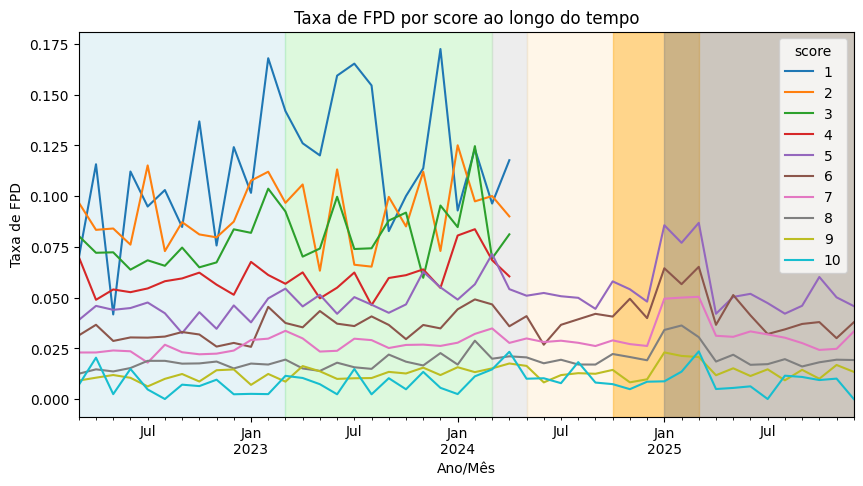

In [ ]:
base['ano_mes'] = pd.to_datetime(base['ano_mes'])

# taxa de FPD por mês e score
tabela = pd.pivot_table(
    base,
    values='FPD',
    index='ano_mes',
    columns='score',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10,5))

tabela.plot(ax=ax)

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
ax.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)  # implantado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

ax.set_title('Taxa de FPD por score ao longo do tempo')
ax.set_xlabel('Ano/Mês')
ax.set_ylabel('Taxa de FPD')

plt.show()

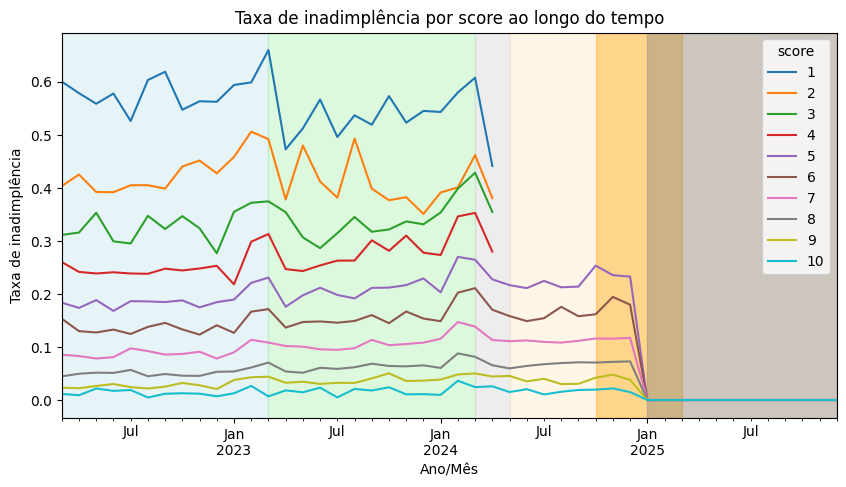

In [ ]:
base['ano_mes'] = pd.to_datetime(base['ano_mes'])

# taxa de inadimplencia por mês e score
tabela = pd.pivot_table(
    base,
    values='target',
    index='ano_mes',
    columns='score',
    aggfunc='mean'
)

fig, tg = plt.subplots(figsize=(10,5))

tabela.plot(ax=tg)

# pintar fundo dos períodos
tg.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)
tg.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)
tg.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)
tg.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3)
tg.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)
tg.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)

tg.set_title('Taxa de inadimplência por score ao longo do tempo')
tg.set_xlabel('Ano/Mês')
tg.set_ylabel('Taxa de inadimplência')

plt.show()

A análise da taxa de inadimplência por score ao longo do tempo indica que a relação entre score e risco permaneceu consistente. Scores mais baixos continuam apresentando maior inadimplência, enquanto scores elevados mantêm taxas significativamente menores. Isso sugere que o modelo continua ordenando adequadamente o risco, mesmo após a implantação do novo modelo. Contudo observa-se alguma mudança na política que retirou os scores de 1 a 4.

### **PILAR 2: DISCRIMINAÇÃO - KS ao longo do tempo**

In [ ]:
# usar apenas contratos efetivados
df_model = base[base["contratado"] == 1].copy()

# função para calcular KS de um mês
def ks_mes(dados):

    bons = dados[dados["target"] == 0]["score"]
    maus = dados[dados["target"] == 1]["score"]

    if len(bons) == 0 or len(maus) == 0:
        return None

    return ks_2samp(bons, maus).statistic

# KS ao longo do tempo
ks_tempo = df_model.groupby("ano_mes").apply(ks_mes).reset_index(name="KS")

print(ks_tempo)

      ano_mes        KS
0  2022-03-01  0.355225
1  2022-04-01  0.339296
2  2022-05-01  0.345219
3  2022-06-01  0.324022
4  2022-07-01  0.299863
5  2022-08-01  0.339779
6  2022-09-01  0.347479
7  2022-10-01  0.341130
8  2022-11-01  0.324987
9  2022-12-01  0.346920
10 2023-01-01  0.315722
11 2023-02-01  0.323722
12 2023-03-01  0.331741
13 2023-04-01  0.299153
14 2023-05-01  0.318042
15 2023-06-01  0.311042
16 2023-07-01  0.320967
17 2023-08-01  0.319731
18 2023-09-01  0.296300
19 2023-10-01  0.292812
20 2023-11-01  0.323195
21 2023-12-01  0.310754
22 2024-01-01  0.294877
23 2024-02-01  0.294533
24 2024-03-01  0.318660
25 2024-04-01  0.308191
26 2024-05-01  0.238276
27 2024-06-01  0.225360
28 2024-07-01  0.239862
29 2024-08-01  0.255181
30 2024-09-01  0.234896
31 2024-10-01  0.242635
32 2024-11-01  0.255290
33 2024-12-01  0.246508
34 2025-01-01       NaN
35 2025-02-01       NaN
36 2025-03-01       NaN
37 2025-04-01       NaN
38 2025-05-01       NaN
39 2025-06-01       NaN
40 2025-07-01   

/tmp/ipykernel_1273/1652430194.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ks_tempo = df_model.groupby("ano_mes").apply(ks_mes).reset_index(name="KS")


A análise da distribuição do target ao longo do tempo mostra ausência de inadimplência observada nos meses mais recentes da base. Isso ocorre porque os contratos ainda não tiveram tempo suficiente para maturar o evento de default. Dessa forma, métricas de discriminação como KS não podem ser avaliadas nesses períodos.

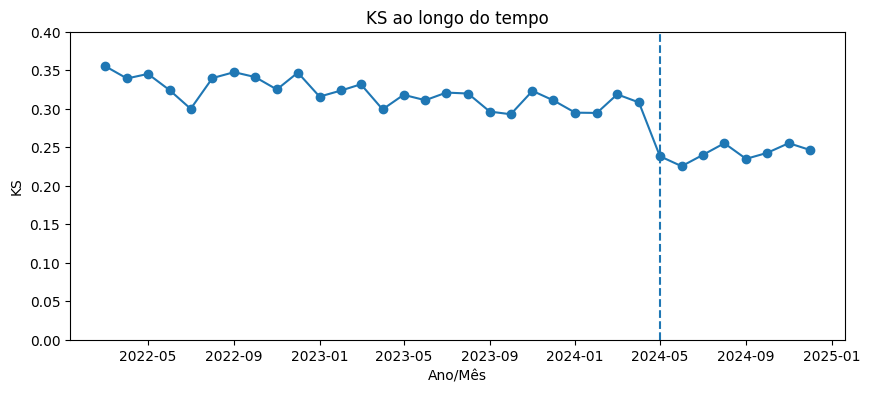

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(ks_tempo["ano_mes"], ks_tempo["KS"], marker="o")

plt.axvline(pd.to_datetime("2024-05-01"), linestyle="--")

plt.title("KS ao longo do tempo")
plt.ylabel("KS")
plt.xlabel("Ano/Mês")
plt.ylim(0,0.4)
plt.show()

In [ ]:
ks_antes = ks_tempo[ks_tempo["ano_mes"] < "2024-05-01"]["KS"].mean()
ks_depois = ks_tempo[ks_tempo["ano_mes"] >= "2024-05-01"]["KS"].mean()

print("KS médio antes:", ks_antes)
print("KS médio depois:", ks_depois)

KS médio antes: 0.32089854772740023
KS médio depois: 0.24225103429442552


*   O modelo apresentou KS médio de aproximadamente 0.32 durante o período de desenvolvimento (modelo + observação);
*   Após a implantação em mai/2024, o KS caiu para aproximadamente 0.24, indicando perda de discriminação;
*   Possível mudança no perfil da carteira ou drift nas variáveis

In [ ]:
maturacao = df_model.groupby(["ano_mes","target"]).size().unstack()

print(maturacao)

target          0.0     1.0
ano_mes                    
2022-03-01  13346.0  1831.0
2022-04-01  13456.0  1760.0
2022-05-01  13215.0  1763.0
2022-06-01  13448.0  1766.0
2022-07-01  13589.0  1824.0
2022-08-01  13362.0  1841.0
2022-09-01  13304.0  1820.0
2022-10-01  13432.0  1846.0
2022-11-01  13398.0  1789.0
2022-12-01  13313.0  1769.0
2023-01-01  13253.0  1857.0
2023-02-01  12848.0  2230.0
2023-03-01  12922.0  2293.0
2023-04-01  13081.0  1883.0
2023-05-01  13251.0  1936.0
2023-06-01  13151.0  1944.0
2023-07-01  13371.0  1947.0
2023-08-01  13312.0  2022.0
2023-09-01  13005.0  2179.0
2023-10-01  12888.0  2065.0
2023-11-01  12934.0  2166.0
2023-12-01  12811.0  2114.0
2024-01-01  13043.0  2118.0
2024-02-01  12343.0  2679.0
2024-03-01  12497.0  2715.0
2024-04-01  12894.0  2216.0
2024-05-01  13571.0  1823.0
2024-06-01  13361.0  1752.0
2024-07-01  13474.0  1838.0
2024-08-01  13334.0  1845.0
2024-09-01  13563.0  1837.0
2024-10-01  15118.0  2103.0
2024-11-01  14841.0  2173.0
2024-12-01  15095.0 

**PILAR 2: DISCRIMINAÇÃO - KS + carta de controle ao longo do tempo**

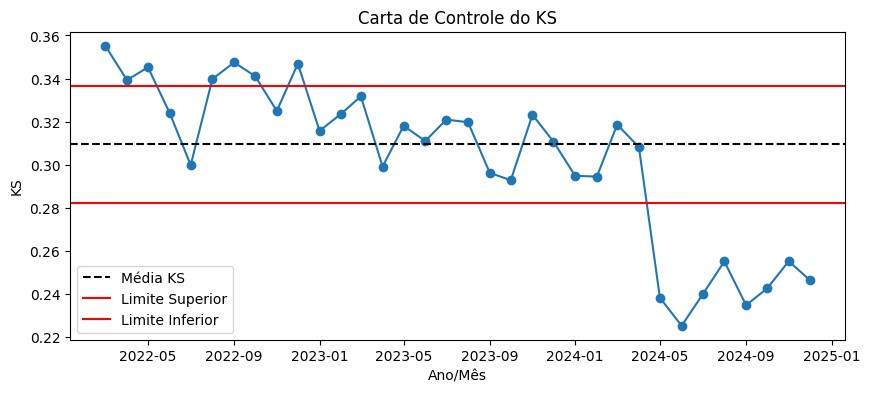

In [ ]:
obs = ks_tempo[
    (ks_tempo["ano_mes"] >= "2023-03-01") &
    (ks_tempo["ano_mes"] <= "2024-02-01")
]

media = obs["KS"].mean()
std = obs["KS"].std()

ucl = media + 2*std
lcl = media - 2*std

plt.figure(figsize=(10,4))

plt.plot(ks_tempo["ano_mes"], ks_tempo["KS"], marker="o")

plt.axhline(media, linestyle="--", color="black", label="Média KS")
plt.axhline(ucl, linestyle="-", color="red", label="Limite Superior")
plt.axhline(lcl, linestyle="-", color="red", label="Limite Inferior")

plt.title("Carta de Controle do KS")
plt.xlabel("Ano/Mês")
plt.ylabel("KS")

plt.legend()

plt.show()

A carta de controle do KS indica comportamento estável do modelo até abril de 2024.
A partir de maio de 2024 observa-se queda abrupta do KS, com valores abaixo do limite inferior de controle. Essa mudança coincide com a implantação do novo modelo, sugerindo perda de capacidade discriminatória.

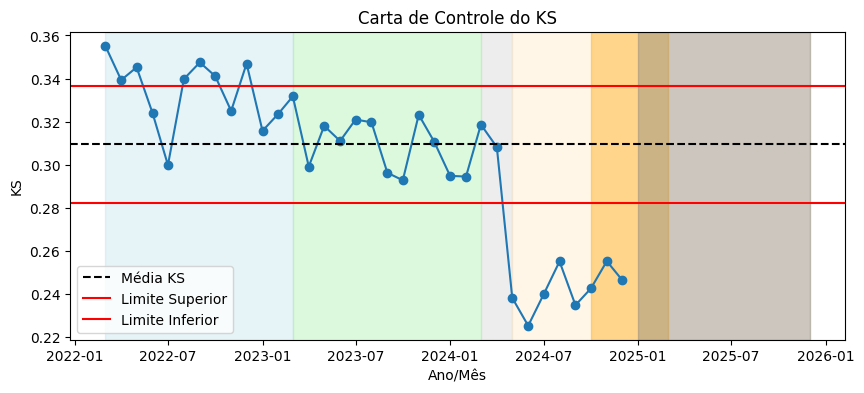

In [ ]:
obs = ks_tempo[
    (ks_tempo["ano_mes"] >= "2023-03-01") &
    (ks_tempo["ano_mes"] <= "2024-02-01")
]

media = obs["KS"].mean()
std = obs["KS"].std()

ucl = media + 2*std
lcl = media - 2*std

fig, ax = plt.subplots(figsize=(10,4))

ax.plot(ks_tempo["ano_mes"], ks_tempo["KS"], marker="o")

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
ax.axvspan('2024-05-01', ks_tempo["ano_mes"].max(), color='moccasin', alpha=0.3)  # implantado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

# linhas de controle
ax.axhline(media, linestyle="--", color="black", label="Média KS")
ax.axhline(ucl, linestyle="-", color="red", label="Limite Superior")
ax.axhline(lcl, linestyle="-", color="red", label="Limite Inferior")

ax.set_title("Carta de Controle do KS")
ax.set_xlabel("Ano/Mês")
ax.set_ylabel("KS")

ax.legend()

plt.show()

**DISCRIMINAÇÃO - KS + carta de controle ao longo do tempo + condicional**

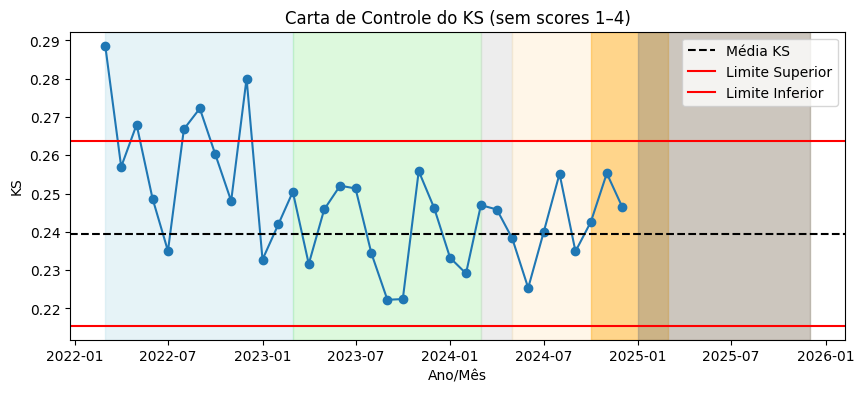

In [ ]:
# remover scores 1,2,3,4
base_filtrada = base[~base["score"].isin([1,2,3,4])]

# calcular KS por mês
ks_lista = []

for mes, dados in base_filtrada.groupby("ano_mes"):

    bons = dados[dados["target"] == 0]["score"]
    maus = dados[dados["target"] == 1]["score"]

    if len(bons) > 0 and len(maus) > 0:
        ks = ks_2samp(maus, bons).statistic
    else:
        ks = np.nan

    ks_lista.append({"ano_mes": mes, "KS": ks})

ks_tempo = pd.DataFrame(ks_lista)

# período de observação para carta de controle
obs = ks_tempo[
    (ks_tempo["ano_mes"] >= "2023-03-01") &
    (ks_tempo["ano_mes"] <= "2024-02-01")
]

media = obs["KS"].mean()
std = obs["KS"].std()

ucl = media + 2*std
lcl = media - 2*std

# gráfico
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(ks_tempo["ano_mes"], ks_tempo["KS"], marker="o")

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)   # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)  # observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)   # limbo
ax.axvspan('2024-05-01', ks_tempo["ano_mes"].max(), color='moccasin', alpha=0.3)  # implantado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)      # deu ruim
ax.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)        # sem target

# linhas de controle
ax.axhline(media, linestyle="--", color="black", label="Média KS")
ax.axhline(ucl, linestyle="-", color="red", label="Limite Superior")
ax.axhline(lcl, linestyle="-", color="red", label="Limite Inferior")

ax.set_title("Carta de Controle do KS (sem scores 1–4)")
ax.set_xlabel("Ano/Mês")
ax.set_ylabel("KS")

ax.legend()

plt.show()

### **PILAR 3: PREVISIBILIDADE**

CÁLCULO DE GH

In [ ]:
# filtrar período da modelagem
base_modelagem = base[
    (base["ano_mes"] >= "2023-03-01") &
    (base["ano_mes"] <= "2024-02-01")
]

# inadimplência média por score
inad_score = (
    base_modelagem
    .groupby("score")["target"]
    .mean()
    .reset_index()
)

inad_score.rename(columns={"target": "inad_media"}, inplace=True)

print(inad_score)

# =========================
# quantidade de contratados
# =========================
tabela = pd.pivot_table(
    base,
    values="contratado",
    index="ano_mes",
    columns="score",
    aggfunc="sum",
    fill_value=0
)

# =========================
# transformar em percentual da linha
# =========================
tabela_perc = tabela.div(tabela.sum(axis=1), axis=0)

print(tabela_perc)

# transformar inad_media em vetor alinhado com as colunas
vetor_pd = inad_score.set_index("score")["inad_media"]

# equivalente ao SOMARPRODUTO
inad_esperada = tabela_perc.mul(vetor_pd, axis=1).sum(axis=1)

inad_esperada = inad_esperada.reset_index()
inad_esperada.columns = ["ano_mes", "inad_esperada"]

print(inad_esperada)

   score  inad_media
0      1    0.544747
1      2    0.411187
2      3    0.336904
3      4    0.280920
4      5    0.212199
5      6    0.156099
6      7    0.107578
7      8    0.063874
8      9    0.037925
9     10    0.016410
score             1         2         3         4         5         6   \
ano_mes                                                                  
2022-03-01  0.007577  0.016341  0.038545  0.065889  0.118535  0.168215   
2022-04-01  0.009661  0.015773  0.038315  0.067232  0.118888  0.167127   
2022-05-01  0.008012  0.016691  0.039725  0.068033  0.121578  0.165710   
2022-06-01  0.007625  0.017287  0.040226  0.067438  0.121730  0.173327   
2022-07-01  0.007526  0.016350  0.038928  0.063129  0.118731  0.163109   
2022-08-01  0.008946  0.016247  0.038085  0.068013  0.121423  0.168914   
2022-09-01  0.007802  0.015935  0.041656  0.066781  0.118157  0.158291   
2022-10-01  0.007658  0.016952  0.041367  0.067286  0.117816  0.166776   
2022-11-01  0.007836  0.01488

Maior gap após implantação:
ano_mes          2024-11-01 00:00:00
inad_esperada               0.111401
inad_real                   0.127718
gap_pp                      0.016318
Name: 32, dtype: object


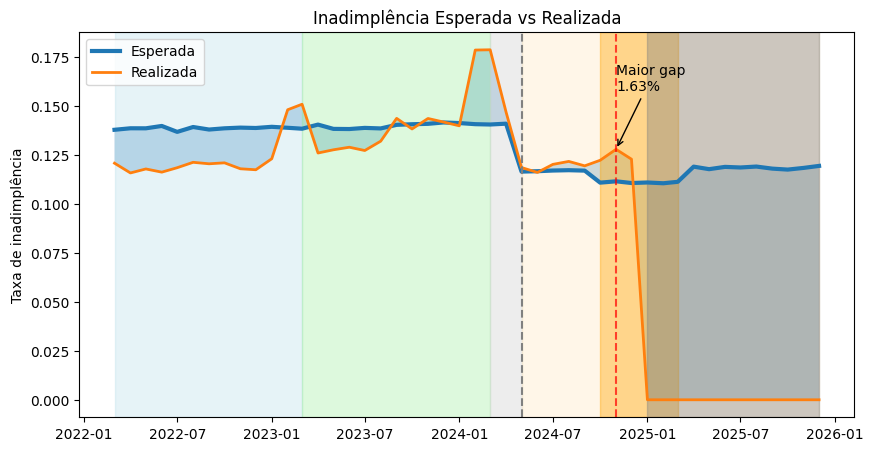

In [ ]:
# =========================
# apenas contratos aprovados
# =========================
base_contratados = base[base["contratado"] == 1]

# =========================
# período de modelagem
# =========================
base_modelagem = base_contratados[
    (base_contratados["ano_mes"] >= "2023-03-01") &
    (base_contratados["ano_mes"] <= "2024-02-01")
]

# =========================
# inadimplência média por score
# =========================
inad_score = (
    base_modelagem
    .groupby("score")["target"]
    .mean()
    .reset_index()
)

inad_score.rename(columns={"target": "inad_media"}, inplace=True)

# =========================
# quantidade de contratos por score
# =========================
tabela = pd.pivot_table(
    base_contratados,
    values="contratado",
    index="ano_mes",
    columns="score",
    aggfunc="sum",
    fill_value=0
)

# =========================
# distribuição percentual
# =========================
tabela_perc = tabela.div(tabela.sum(axis=1), axis=0)

# =========================
# vetor de PD
# =========================
vetor_pd = inad_score.set_index("score")["inad_media"]

# =========================
# inadimplência esperada
# =========================
inad_esperada = tabela_perc.mul(vetor_pd, axis=1).sum(axis=1)

inad_esperada = inad_esperada.reset_index()
inad_esperada.columns = ["ano_mes", "inad_esperada"]

# =========================
# inadimplência realizada
# =========================
inad_real = (
    base_contratados
    .groupby("ano_mes")["target"]
    .mean()
    .reset_index()
)

inad_real.columns = ["ano_mes", "inad_real"]

# =========================
# juntar resultados
# =========================
df_plot = inad_esperada.merge(inad_real, on="ano_mes")

# gap em pontos percentuais
df_plot["gap_pp"] = df_plot["inad_real"] - df_plot["inad_esperada"]

# =========================
# maior gap após implantação
# =========================
df_implantado = df_plot[
    (df_plot["ano_mes"] >= "2024-05-01") &
    (df_plot["ano_mes"] < "2025-01-01")
]

pior_mes = df_implantado.loc[df_implantado["gap_pp"].abs().idxmax()]

print("Maior gap após implantação:")
print(pior_mes)

# =========================
# gráfico
# =========================
plt.figure(figsize=(10,5))

plt.plot(df_plot["ano_mes"], df_plot["inad_esperada"],
         label="Esperada", linewidth=3)

plt.plot(df_plot["ano_mes"], df_plot["inad_real"],
         label="Realizada", linewidth=2)

plt.fill_between(
    df_plot["ano_mes"],
    df_plot["inad_real"],
    df_plot["inad_esperada"],
    alpha=0.3
)

# linha da implantação
plt.axvline(pd.to_datetime("2024-05-01"),
            linestyle="--", color="gray")

# marcar maior gap
plt.axvline(pior_mes["ano_mes"],
            color="red",
            linestyle="--",
            alpha=0.7)

plt.annotate(
    f'Maior gap\n{pior_mes["gap_pp"]:.2%}',
    xy=(pior_mes["ano_mes"], pior_mes["inad_real"]),
    xytext=(pior_mes["ano_mes"], pior_mes["inad_real"] + 0.03),
    arrowprops=dict(arrowstyle="->")
)

# =========================
# pintar períodos
# =========================
plt.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3)
plt.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3)
plt.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4)
plt.axvspan('2024-05-01', df_plot["ano_mes"].max(), color='moccasin', alpha=0.3)
plt.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4)
plt.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4)

plt.title("Inadimplência Esperada vs Realizada")
plt.ylabel("Taxa de inadimplência")
plt.legend()

plt.show()

# **ANÁLISE BIVARIADA**

## Score por contratado

In [18]:
tabela_contagem = base.groupby(["ano_mes", "score"]).agg(
    total_id=("id", "count"),
    contratado=("contratado", lambda x: (x == 1).sum()),
    nao_contratado=("contratado", lambda x: (x == 0).sum())
).reset_index()

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(tabela_contagem)

       ano_mes  score  total_id  contratado  nao_contratado
0   2022-03-01      1       611         115             496
1   2022-03-01      2       814         248             566
2   2022-03-01      3      1408         585             823
3   2022-03-01      4      1773        1000             773
4   2022-03-01      5      2646        1799             847
5   2022-03-01      6      3187        2553             634
6   2022-03-01      7      4307        3796             511
7   2022-03-01      8      3089        2889             200
8   2022-03-01      9      1818        1758              60
9   2022-03-01     10       442         434               8
10  2022-04-01      1       681         147             534
11  2022-04-01      2       768         240             528
12  2022-04-01      3      1370         583             787
13  2022-04-01      4      1805        1023             782
14  2022-04-01      5      2599        1809             790
15  2022-04-01      6      3155        2

## Score por contratado por restrição

In [70]:
# filtro
df = base[
    (base["ano_mes"] >= "2024-08-01") &
    (base["ano_mes"] < "2025-01-01")
].copy()

tabela = pd.crosstab(
    [df["score"],df["qt_restr"],df["ano_mes"]],
    df["target"],
    normalize="index"
) * 100

print(tabela.round(2))


target                        0.0    1.0
score qt_restr ano_mes                  
5     0        2024-08-01   80.38  19.62
               2024-09-01   79.69  20.31
               2024-10-01   72.18  27.82
               2024-11-01   73.05  26.95
               2024-12-01   74.92  25.08
      1        2024-08-01   77.45  22.55
               2024-09-01   78.96  21.04
               2024-10-01   81.51  18.49
               2024-11-01   86.15  13.85
               2024-12-01   81.33  18.67
      2        2024-08-01   76.63  23.37
               2024-09-01   76.44  23.56
               2024-10-01   86.41  13.59
               2024-11-01   89.95  10.05
               2024-12-01   88.27  11.73
      >2       2024-08-01   77.34  22.66
               2024-09-01   77.47  22.53
               2024-10-01   88.52  11.48
               2024-11-01   92.86   7.14
               2024-12-01   83.33  16.67
6     0        2024-08-01   83.20  16.80
               2024-09-01   84.71  15.29
               2

**CORRELAÇÃO**

Correlação: 0.8698148976267956


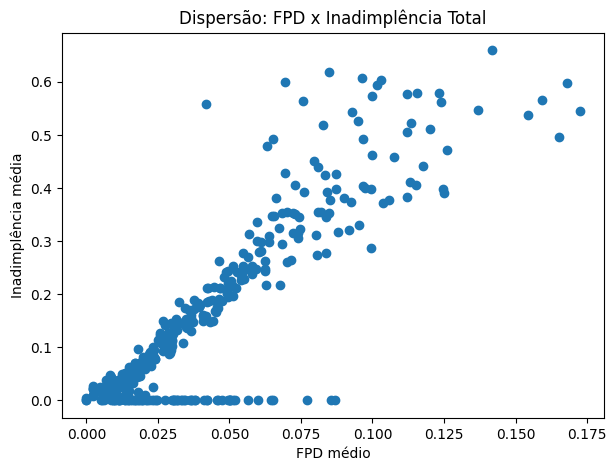

In [20]:
# usar apenas contratos aprovados
df = base[base["contratado"] == 1].copy()

# calcular médias por mês e score (igual ao Excel)
tabela = df.groupby(["ano_mes","score"]).agg(
    fpd_media=("FPD","mean"),
    inad_media=("target","mean")
).reset_index()

# correlação
corr = tabela["fpd_media"].corr(tabela["inad_media"])
print("Correlação:", corr)

# gráfico de dispersão
plt.figure(figsize=(7,5))

plt.scatter(
    tabela["fpd_media"],
    tabela["inad_media"]
)

plt.title("Dispersão: FPD x Inadimplência Total")
plt.xlabel("FPD médio")
plt.ylabel("Inadimplência média")

plt.show()

In [71]:
base.groupby("qt_restr")["target"].mean()

,target
qt_restr,
0,0.083458
1,0.116186
2,0.139862
>2,0.183706
